# Methodology

###  Previous methodology used


Before, the proccess used was a visual analysis of graphs. In order to achieve reproducibility, it was searching visually for features with a common behavior in a specified datetime. Let's say a feature X showed a growth in the selected timespan for a specific operation , this growth could be observed in other features for the same kind of operation and timespan?

This reproducibility should be defined for operations of the same type. 

### Defining the operation type

The type of an operation is being defined by two parameters, the 'op', which means the type of operation itself, and the 'obs', which tells if the operation was a WIN or LOSS.

Thus, we are defining the operations as the following possibilities:

* Sell:
    - WIN
    - LOSS

* Buy
    - WIN
    - LOSS
    
We're going to focus firstly in Sell + WIN operations.

### Defining the methodology used to filter features

Since we're searching for features which presents the same behavior in a specified timespan, we could use a first order derivate and get the signal of the result. A positive sign indicates growth, a negative sign indicates degrowth and no sign indicates constantness.

BUT, we're handling discrete values in a short period of time. A derivative is not needed. A subtract operation should suffice.

Thus, we end up with the following criteria:

- Feature[T(x)] - Feature[T(x - 1)] > 0 (Growth)
- Feature[T(x)] - Feature[T(x - 1)] = 0 (Constantness)
- Feature[T(x)] - Feature[T(x - 1)] < 0 (Degrowth)

# Case Study

## Enviroment Setup

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.stattools import ccf
from sklearn import preprocessing
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
import dash
from dash import dcc, html, Input, Output
import scipy.stats as stats
import pickle

from datetime import datetime
from datetime import timedelta

pd.set_option('use_inf_as_na', True)
pd.set_option('display.max_columns', None)
warnings.simplefilter("ignore", UserWarning)

/tmp/ipykernel_3142160/477386657.py:18: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('use_inf_as_na', True)


## Defining functions

In [3]:
def get_sign(number):
    if number > 0:
        return 1
    if number < 0:
        return -1

    return None

def get_feature_variation_over_time(dataframe, feature):
    length = len(dataframe)
    variation = []
    for row in range(0, length - 1):
        variation.append((dataframe[feature].iloc[row + 1] - dataframe[feature].iloc[row]))
    return variation

def has_same_behavior_over_time(dataframes, feature):
    feature_variation_df_0 = get_feature_variation_over_time(dataframes[0], feature)
    feature_variation_df_1 = get_feature_variation_over_time(dataframes[1], feature)

    comparisons = []
    for occurrence in range(0, len(feature_variation_df_0)):
        comparisons.append(get_sign(feature_variation_df_0[occurrence]) == get_sign(feature_variation_df_1[occurrence]))

    return comparisons

def calculate_percentage_of_occurrences(array, element):
    count = array.count(element)
    total_elements = len(array)
    percentage = (count / total_elements) if total_elements > 0 else 0

    return percentage

def optimal_grid(number_of_datasets):
    nrows = int(number_of_datasets / 2 if (number_of_datasets % 2 == 0) else number_of_datasets // 3 + 1)
    ncols = int(2 if (number_of_datasets % 2 == 0) else 3)
    return nrows, ncols

def optimal_figsize(ncols):
    return (20, 10) if ncols % 3 == 0 else (15, 5)

def report_features(features_manager, features):
    excluded = features_manager['excluded']
    included = features_manager['included']

    print(f'Total of features was: {len(features)}')
    print(f'Features dropped: {len(excluded)}')
    print(f'Features remaining: {len(included)}')

def find_highly_correlated_pairs(dataframe, threshold):
    corr_matrix = dataframe.corr()
    highly_correlated_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname1 = corr_matrix.columns[i]
                colname2 = corr_matrix.columns[j]
                highly_correlated_pairs.append((colname1, colname2))
    return highly_correlated_pairs

def find_smallest_dataframe_length(dataframes):
    if not dataframes:
        return 0
    lengths = [len(df) for df in dataframes]
    return min(lengths)

def get_normalized_feature(dataframe, feature, normalization_type = None):
    if normalization_type is not None:
        if normalization_type == 'SCALING':
            return (dataframe[feature] - dataframe[feature].min()) / (dataframe[feature].max() - dataframe[feature].min())

        if normalization_type == 'Z-SCORE':
            return (dataframe[feature] - dataframe[feature].mean()) / dataframe[feature].std()

    return (dataframe[feature]) / dataframe[feature].max()

def filter_based_on_behavior_over_time(dataframes, features, threshold = 0.8):
    included_features = set(features['included'])
    excluded_features = set(features['excluded'])

    for feature in features['included']:
        for i in range(len(dataframes)):
            for j in range(i + 1, len(dataframes)):
                dataframe1 = dataframes[i]
                dataframe2 = dataframes[j]

                compare = has_same_behavior_over_time(dataframes=[dataframe1, dataframe2], feature=feature)
                percentage = calculate_percentage_of_occurrences(array=compare, element=True)

                if percentage >= threshold:
                    included_features.add(feature)
                    excluded_features.discard(feature)
                else:
                    excluded_features.add(feature)
                    included_features.discard(feature)

    return list(included_features), list(excluded_features)


## Defining the DataFrame

In [4]:
PATH        = "./data_win/"
VERSION     = 'data11'
FILENAME    = 'WIN_DATASET_normas_' + VERSION + '.csv'
ALL_FEATURES= [
    'id',                       #
    'datetime',                 #
    'decisao',                  #
    'ampmedia',                 # Average amplitude (of what?)
    'tp',                       # Take Profit
    'sl',                       # Stop Loss
    'stdDev_buffer_0',          # Standard Deviation (of what?) Buffer 0 (02s)
    'stdDev_buffer_1',          # Standard Deviation (of what?) Buffer 1 (60s)
    'iTrades',                  # Individual Trades
    'dDifPrecoCum',             #
    'dDifVolCum',               #
    'dDifVolCum_div_iTrades',   #
    'dVol',                     #
    'iATR_buffer_0',            #
    'dDifLastAsk1',             #
    'dDifLastBid1',             #
    'dBid',                     #
    'dAsk',                     #
    'dMedDifVolCum',            #
    'dAvgDifVolCum',            #
    'dStdDifVolCum',            #
    'dMaxDifVolCum',            #
    'dMinDifVolCum',            #
    'dAmpDifVolCum',            #
    'dAssDifVolCum',            #
    'dCurDifVolCum',            #
    'dMedDifPrecoCum',          #
    'dAvgDifPrecoCum',          #
    'dStdDifPrecoCum',          #
    'dMaxDifPrecoCum',          #
    'dMinDifPrecoCum',          #
    'dAmpDifPrecoCum',          #
    'dAssDifPrecoCum',          #
    'dCurDifPrecoCum',          #
    'dMedTrades',               #
    'dAvgTrades',               #
    'dStdTrades',               #
    'dMaxTrades',               #
    'dMinTrades',               #
    'dAmpTrades',               #
    'dAssTrades',               #
    'dCurTrades',               #
    'dMedOfMedDifVolCum',       #
    'dMedOfCurDifVolCum',       #
    'dMedOfAssDifVolCum',       #
    'dMedOfMedDifPrecoCum',     #
    'dMedOfCurDifPrecoCum',     #
    'dMedOfAssDifPrecoCum',     #
    'dMedOfMedTrades',          #
    'dMedOfCurTrades',          #
    'dMedOfAssTrades',          #
    'tat_iQtdeBuy',             #
    'tat_iQtdeSell',            #
    'tat_iQtdeBalance',         #
    'tat_dSumBalance',          #
    'tat_dCurtoseQC',           #
    'tat_dCurtoseQV',           #
    'tat_dPMedPondC',           #
    'tat_dPMedPondV',           #
    'dMedTaTQtdeBuy',           #
    'dMedTaTQtdeSell',          #
    'dMedTaTQtdeBalance',       #
    'dMedTaTSumBalance',        #
    'dMedTaTCurtoseQC',         #
    'dMedTaTCurtoseQV',         #
    'dMedTaTAssimetriaQC',      #
    'dMedTaTAssimetriaQV',      #
    'dMedTaTPMedPondC',         #
    'dMedTaTPMedPondV',         #
    'dAvgTaTQtdeBuy',           #
    'dAvgTaTQtdeSell',          #
    'dAvgTaTQtdeBalance',       #
    'dAvgTaTSumBalance',        #
    'dAvgTaTCurtoseQC',         #
    'dAvgTaTCurtoseQV',         #
    'dAvgTaTAssimetriaQC',      #
    'dAvgTaTAssimetriaQV',      #
    'dAvgTaTPMedPondC',         #
    'dAvgTaTPMedPondV',         #
    'dCurTaTQtdeBuy',           #
    'dCurTaTQtdeSell',          #
    'dCurTaTQtdeBalance',       #
    'dCurTaTSumBalance',        #
    'dCurTaTCurtoseQC',         #
    'dCurTaTCurtoseQV',         #
    'dCurTaTAssimetriaQC',      #
    'dCurTaTAssimetriaQV',      #
    'dCurTaTPMedPondC',         #
    'dCurTaTPMedPondV',         #
    'open',                     #
    'high',                     #
    'low',                      #
    'close',                    #
    'tick_volume',              #
    'real_volume',              #
    'dt',                       #
    'hour',                     #
    'minute',                   #
    'second',                   #
    'ratioPMedPondC',           #
    'ratioPMedPondV',           #
    'ampco',                    #
    'difPMP',                   #
    'difMedPMP',                #
    'difCurQCQV',               #
    'difAvgTaTCur',             #
    'difAvgTaTAss',             #
    'difAvgTaTPMP',             #
    'difCurTaTCur',             #
    'difCurTatAss',             #
    'difCurTatPMP',             #
    'ratioCurTaTQtdeSell',      #
    'ratioCurTaTQtdeBuy',       #
    'tat_iQtdeBalanceAcum',     #
    'tat_dSumBalanceAcum',      #
    'ratio_iQtdeSumAcum',       #
    'norma_L1',                 #
    'norma_L2',                 #
    'norma_p',                  #
    'norma_L_inf',              #
]
OPERATION_TYPES = (
    ('vd', 'win'),
    ('vd', 'loss'),
    ('cp', 'win'),
    ('cp', 'loss'),
)

df              = pd.read_csv(PATH + FILENAME, sep=';',encoding='utf-8')
df.columns      = ALL_FEATURES
df['datetime']  = df['datetime'].apply(lambda x: pd.Timestamp(x))
df['dt']        = df['datetime']
df              = df.set_index('datetime')

df.drop_duplicates(subset=None, keep='first', inplace=True)
df.sort_index(inplace=True)
df.fillna(0, inplace=True)

## Delimiting the DataFrame

In [5]:
training_df         = pd.read_csv(PATH + 'win_dataset_data11.csv', sep=';',encoding='utf-8')
training_df['dt']   = training_df['dt'].apply(lambda x: pd.Timestamp(x))

training_df.set_index(training_df.columns[0], inplace=True)
training_df.index.name = 'id'

operations_datetimes = training_df['dt']

RANGE = {
    'hours':   0,
    'minutes': 1,
    'seconds': 0,
}

operations_dataframes = []
for operation in operations_datetimes:
    start   = operation - pd.Timedelta(hours= RANGE['hours'], minutes=RANGE['minutes'], seconds=RANGE['seconds'])
    end     = operation + pd.Timedelta(hours= RANGE['hours'], minutes=RANGE['minutes'], seconds=RANGE['seconds'])

    df_filtered = df[(df['dt'] >= start) & (df['dt'] <= end)].copy()
    op_value    = training_df.loc[training_df['dt'] == operation, 'op'].iloc[0]
    obs_value   = training_df.loc[training_df['dt'] == operation, 'obs'].iloc[0]

    df_filtered['op']   = op_value
    df_filtered['obs']  = obs_value

    operations_dataframes.append(df_filtered)

fixed_length = find_smallest_dataframe_length(operations_dataframes)

normalized_operations_dataframes = []
for dataframe in operations_dataframes:
    if len(dataframe) > fixed_length:
        normalized_operations_dataframes.append(dataframe.iloc[:fixed_length])

    elif len(dataframe) < fixed_length:
        rows_to_add = fixed_length - len(dataframe)
        padding = pd.DataFrame([dataframe.iloc[-1]] * rows_to_add)
        normalized_dataframe = pd.concat([dataframe, padding], ignore_index=True)
        normalized_operations_dataframes.append(normalized_dataframe)

    else:
        normalized_operations_dataframes.append(dataframe)

operations_dataframes = normalized_operations_dataframes

## Filter features

In [6]:
not_interesting = [
        'id',
        'decisao',
        'tp',
        'sl',
        'datetime',
        'dt',
        'hour',
        'minute',
        'second',
    ]

FEATURES = {
    operation_type: {
        'included': list(filter(lambda x: x not in not_interesting, ALL_FEATURES)),
        'excluded': not_interesting
    } for operation_type in OPERATION_TYPES
}

In [7]:
for operation_type in FEATURES:
    dataframes = []
    for dataframe in operations_dataframes:
        condition = (dataframe['op'] == operation_type[0]) & (dataframe['obs'] == operation_type[1])
        if condition.any():
            dataframes.append(dataframe)


    FEATURES[operation_type]['included'], FEATURES[operation_type]['excluded'] = filter_based_on_behavior_over_time(dataframes = dataframes, features = FEATURES[operation_type], threshold = 0.8)

In [8]:
# Save FEATURES in a pickle to persist data and don't need to run the code every time

# comenting the code just to not overwrite it everytime.
# filename = 'features.pkl'

# with open(filename, 'wb') as file:
#     pickle.dump({'FEATURES': FEATURES}, file)

In [9]:
# Load FEATURES from features.pkl
filename = 'features.pkl'

with open(filename, 'rb') as file:
    loaded_data = pickle.load(file)

    FEATURES = loaded_data['FEATURES']

In [10]:
for operation in OPERATION_TYPES:
    print(f'Operation: {operation}')
    report_features(FEATURES[operation], ALL_FEATURES)
    print()

Operation: ('vd', 'win')
Total of features was: 120
Features dropped: 107
Features remaining: 13

Operation: ('vd', 'loss')
Total of features was: 120
Features dropped: 109
Features remaining: 11

Operation: ('cp', 'win')
Total of features was: 120
Features dropped: 106
Features remaining: 14

Operation: ('cp', 'loss')
Total of features was: 120
Features dropped: 106
Features remaining: 14



In [11]:
operations_datetimes = operations_datetimes.reset_index(drop=True)

## Plotting charts with filtered columns

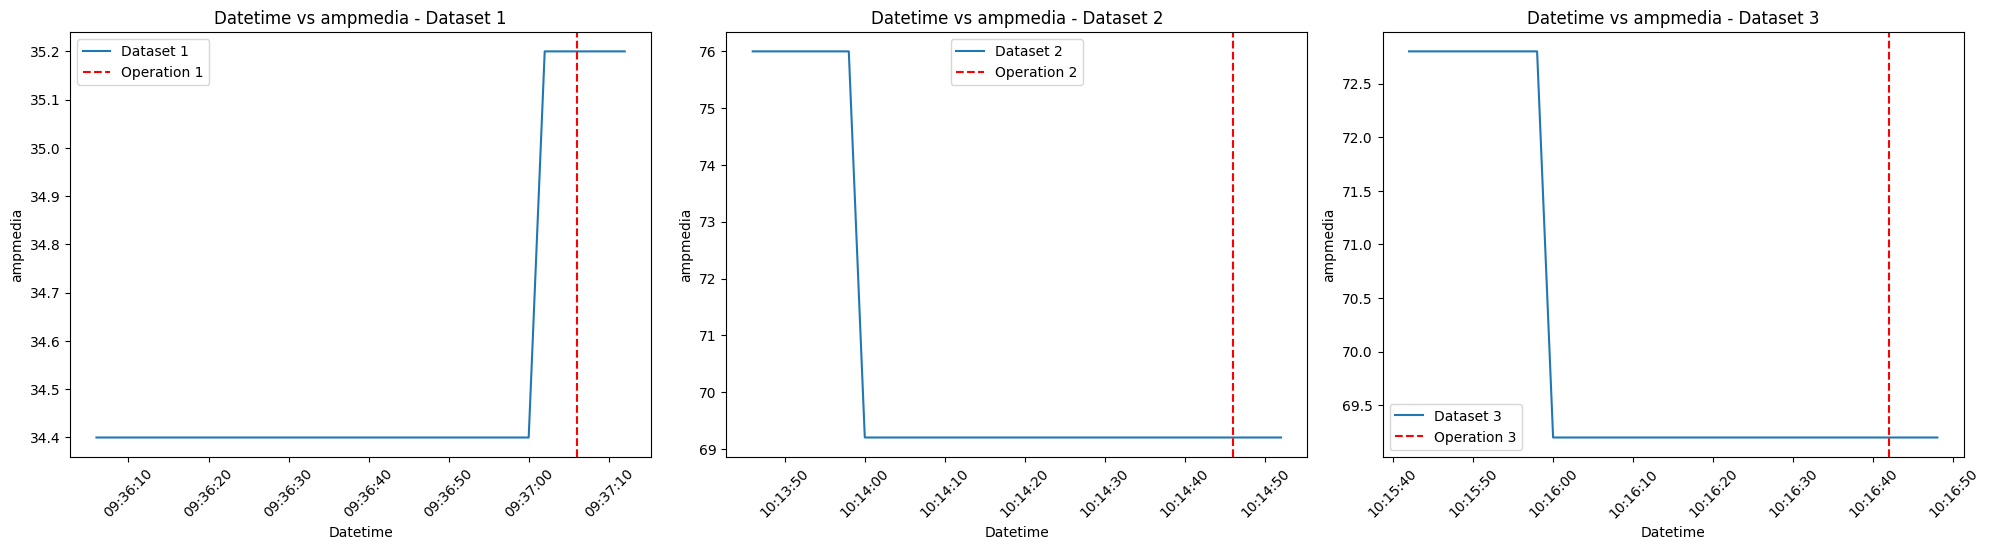

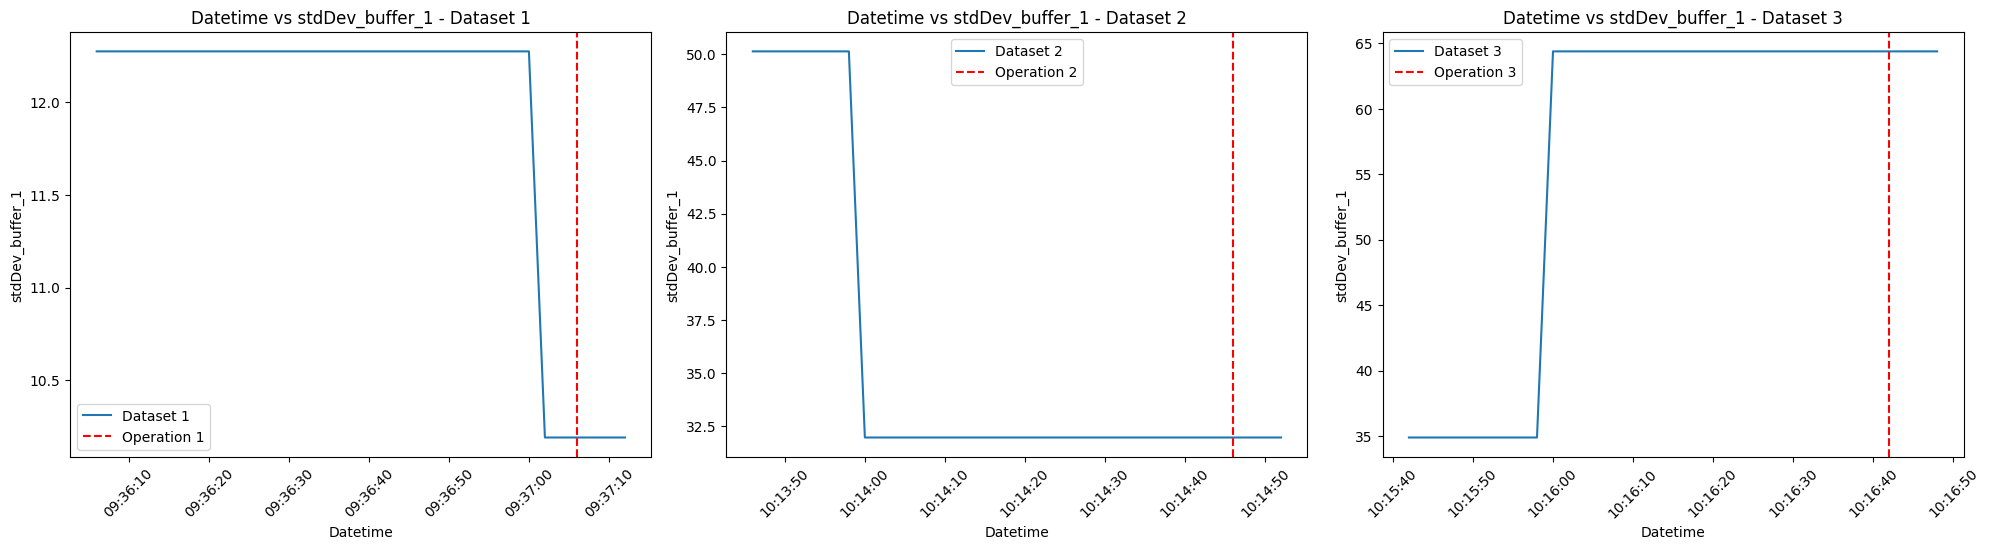

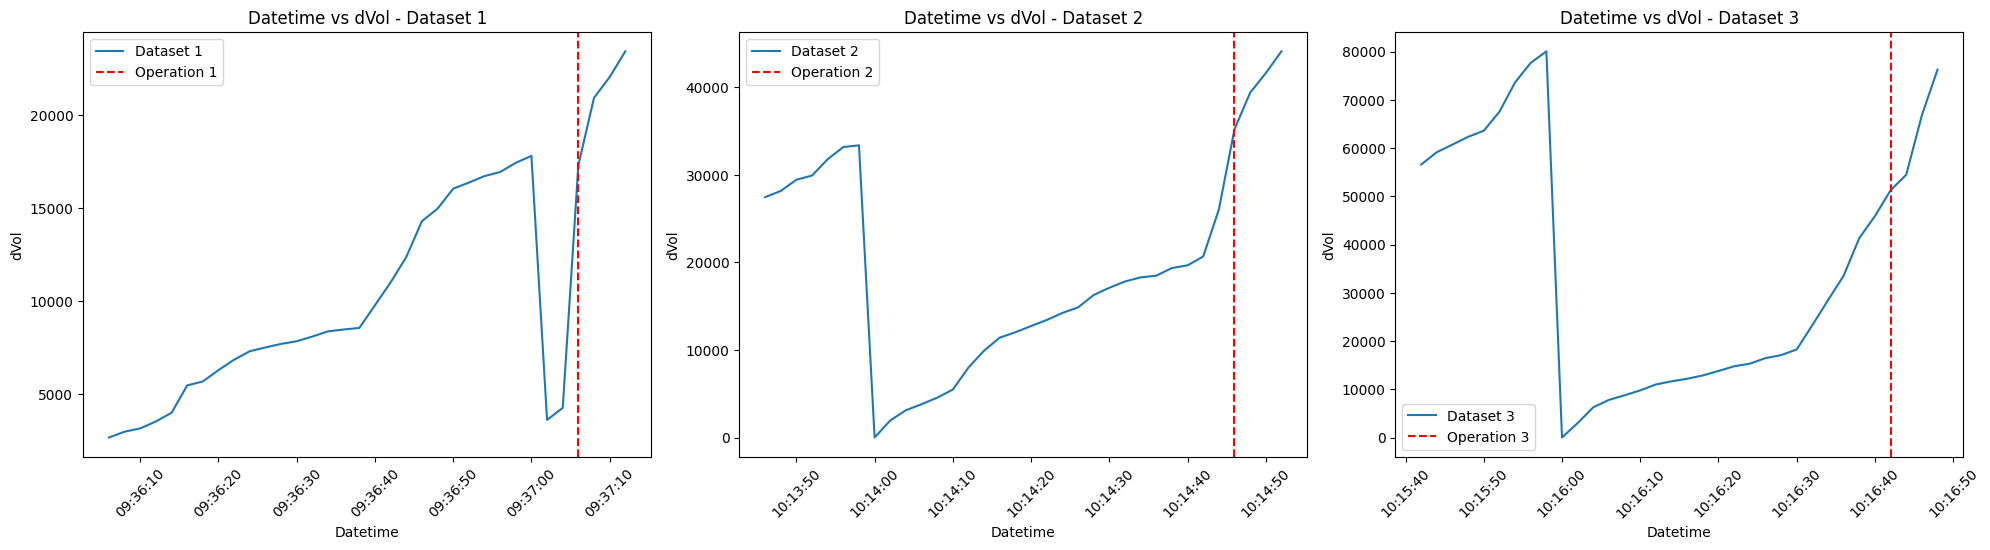

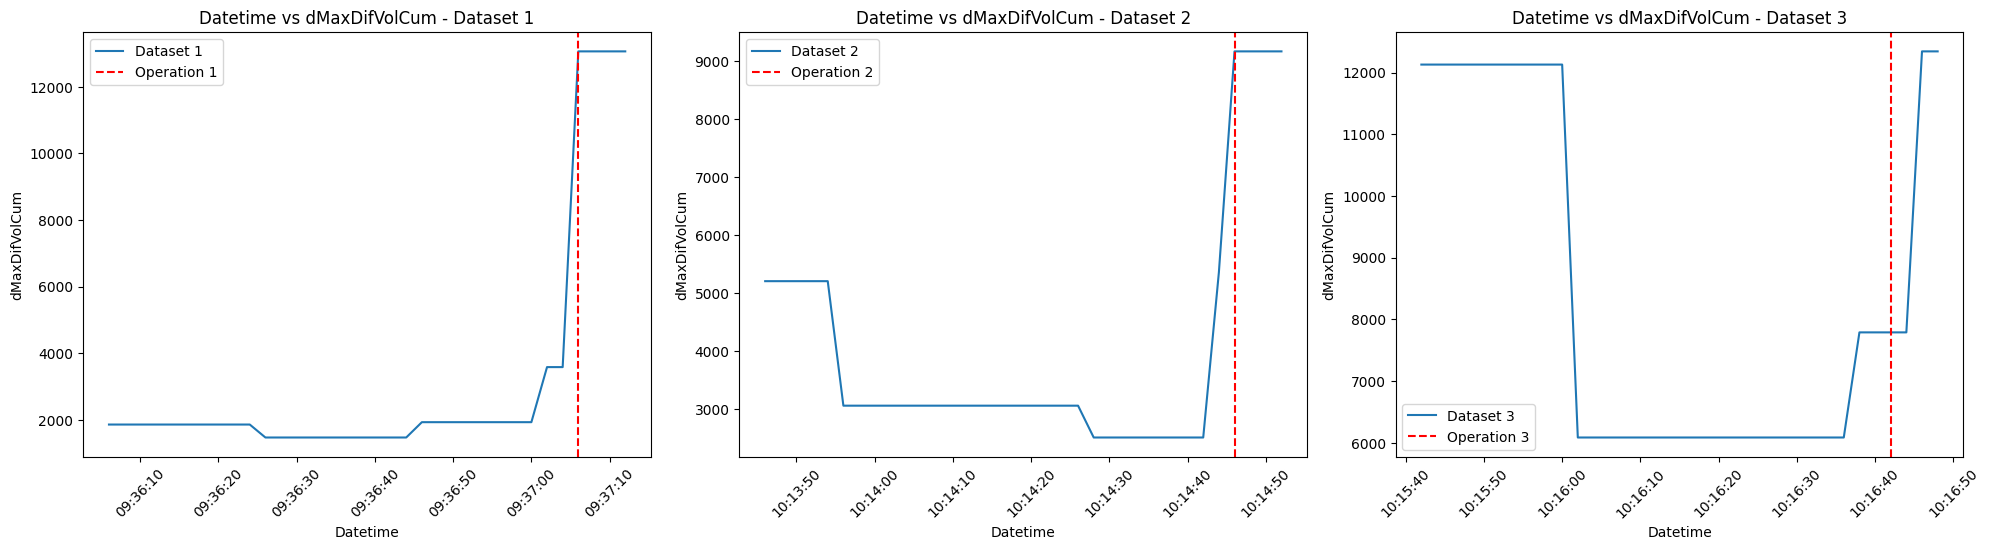

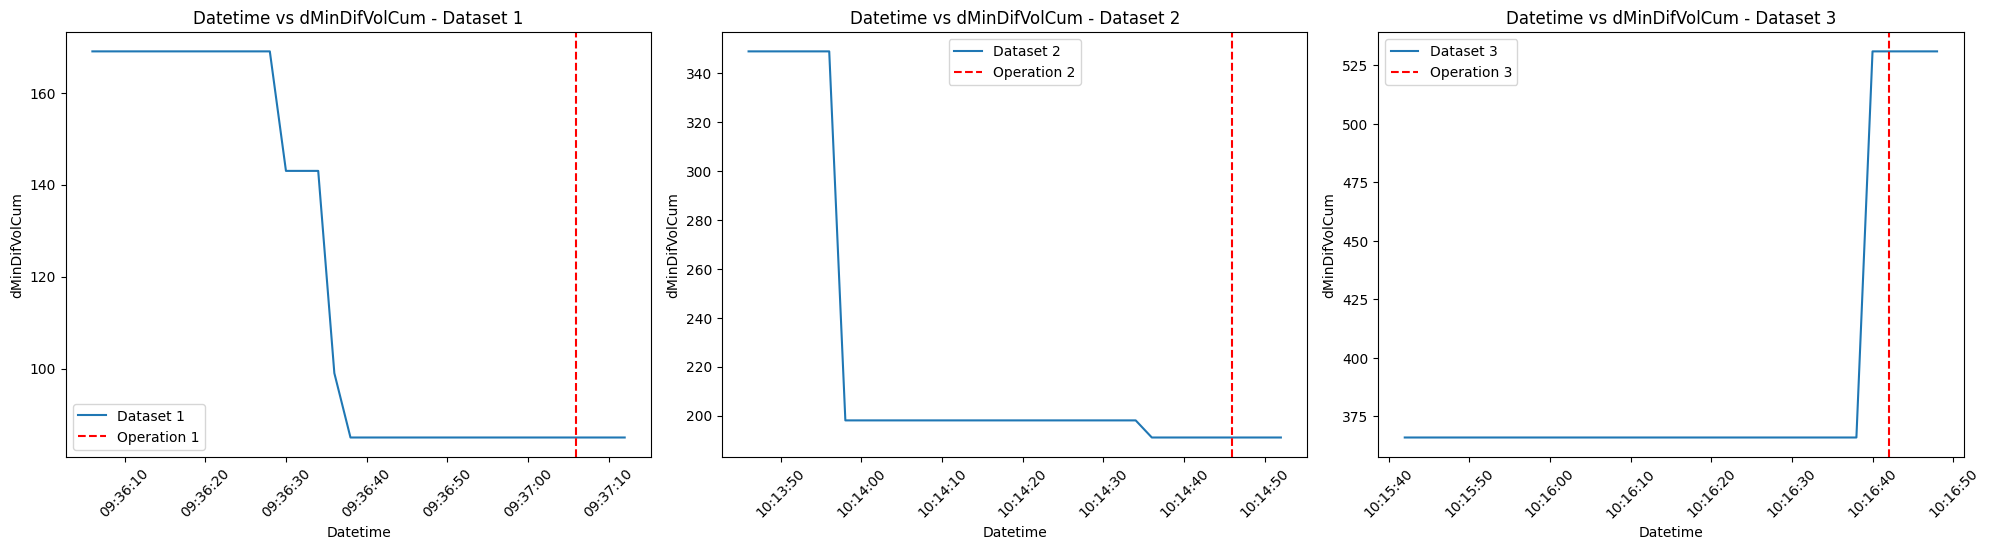

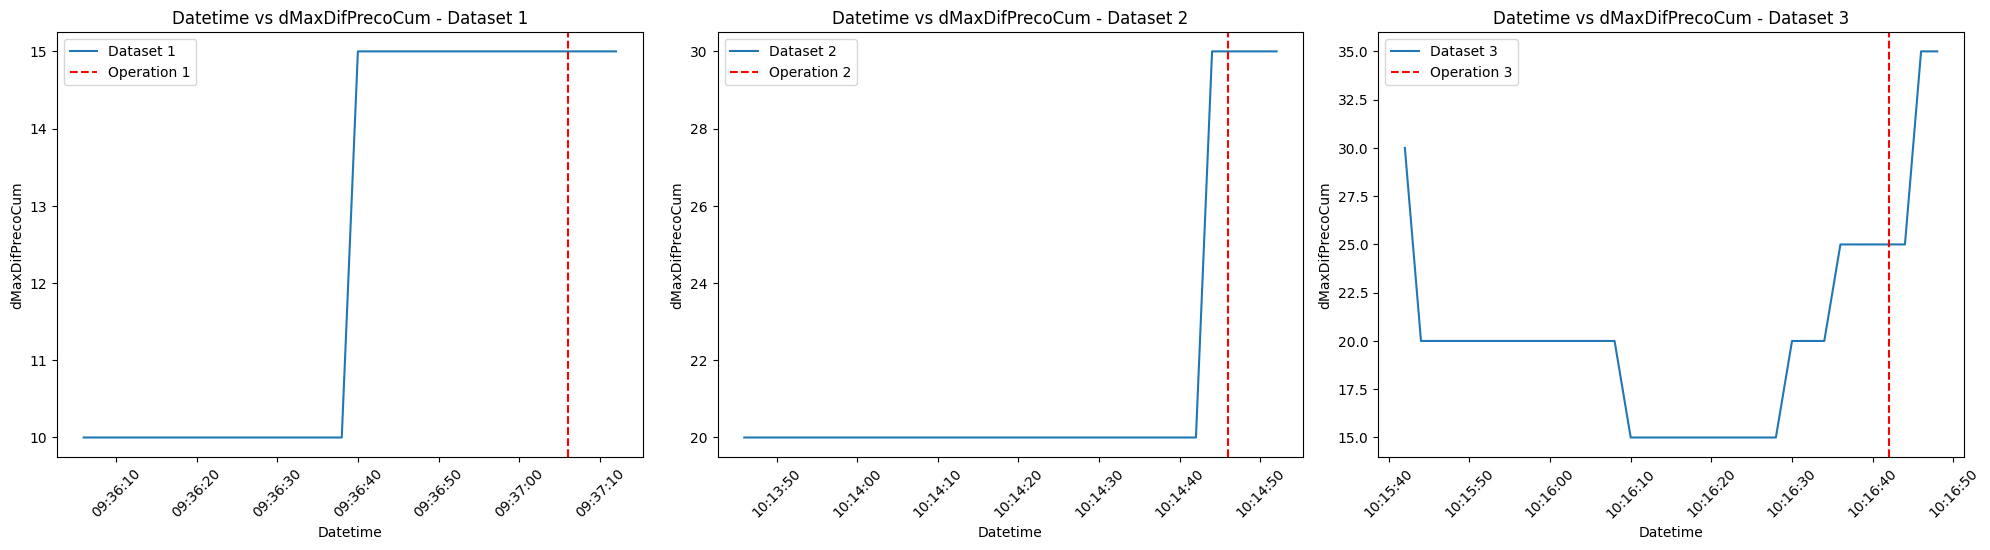

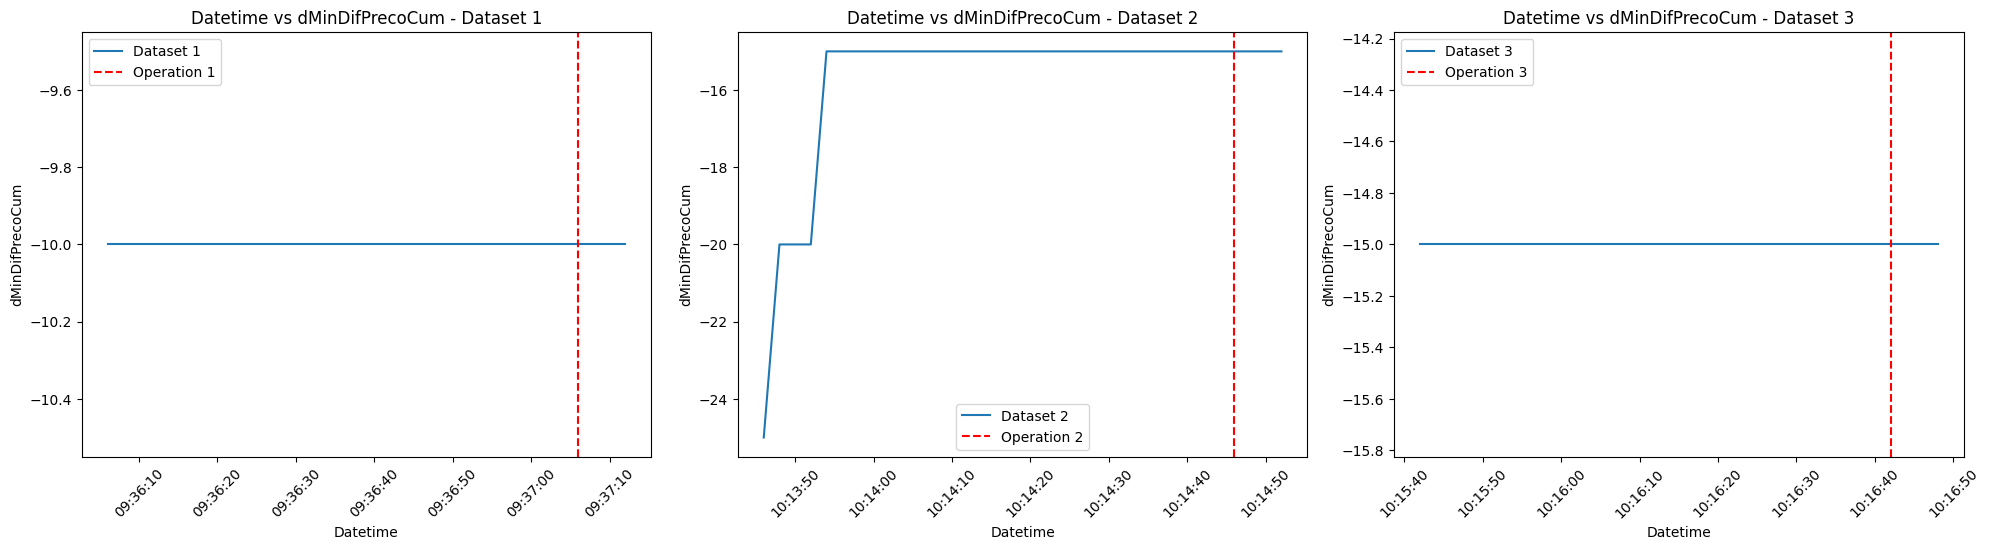

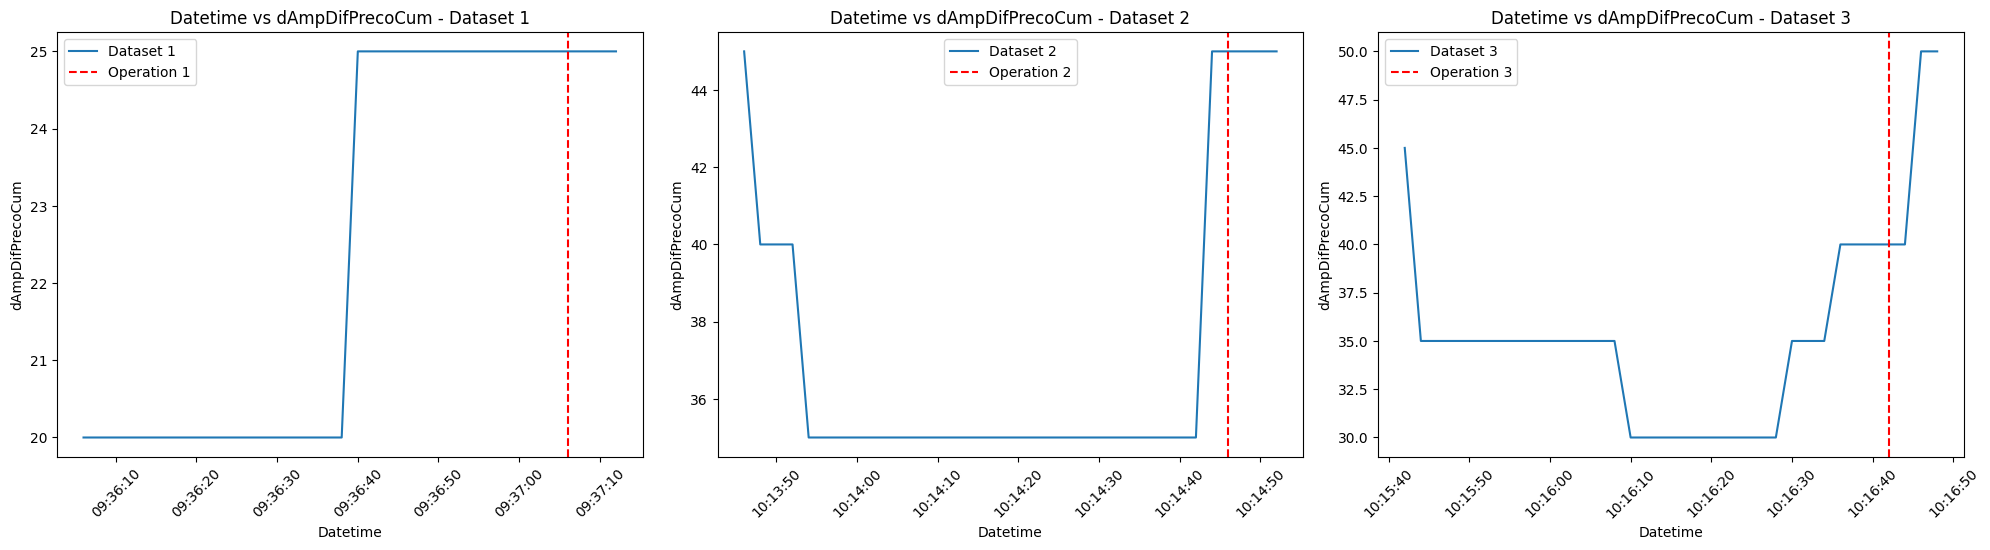

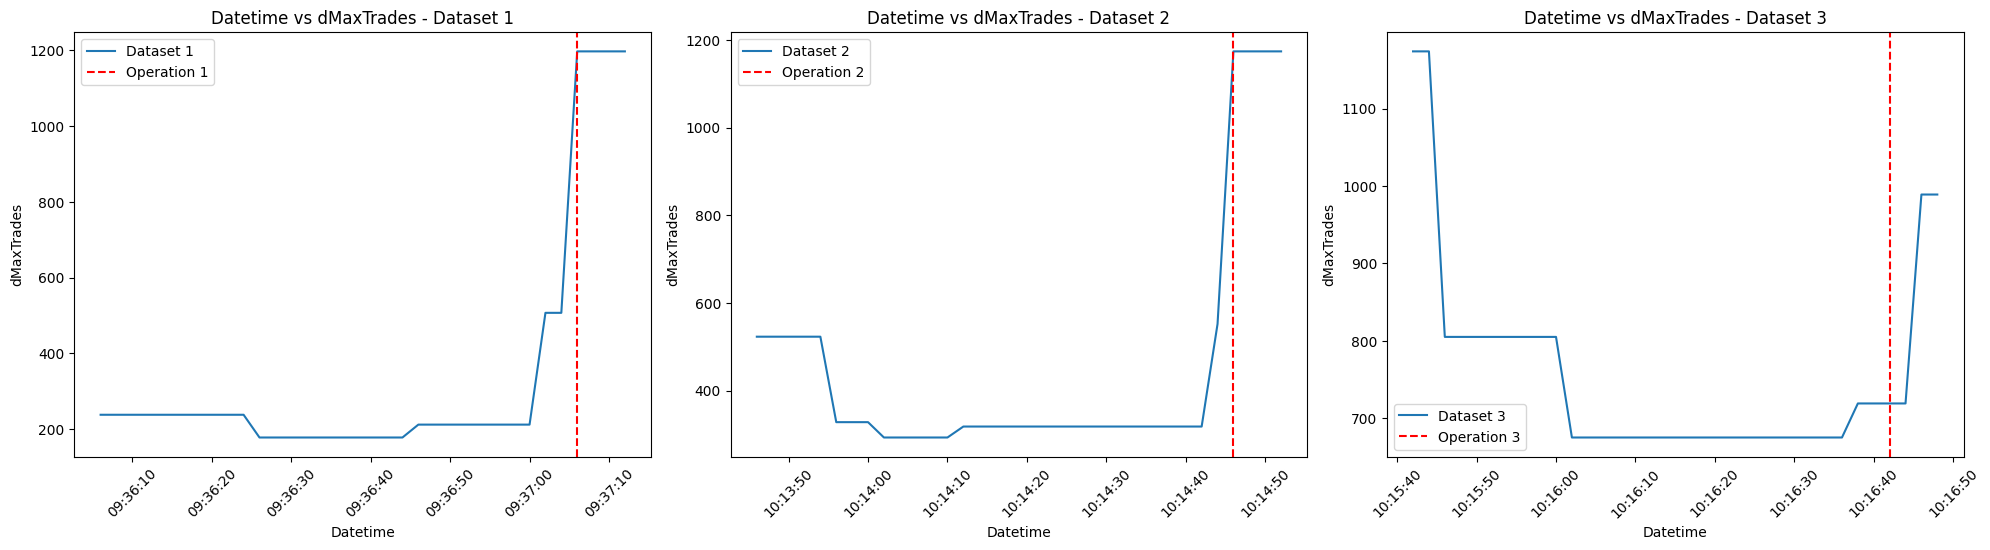

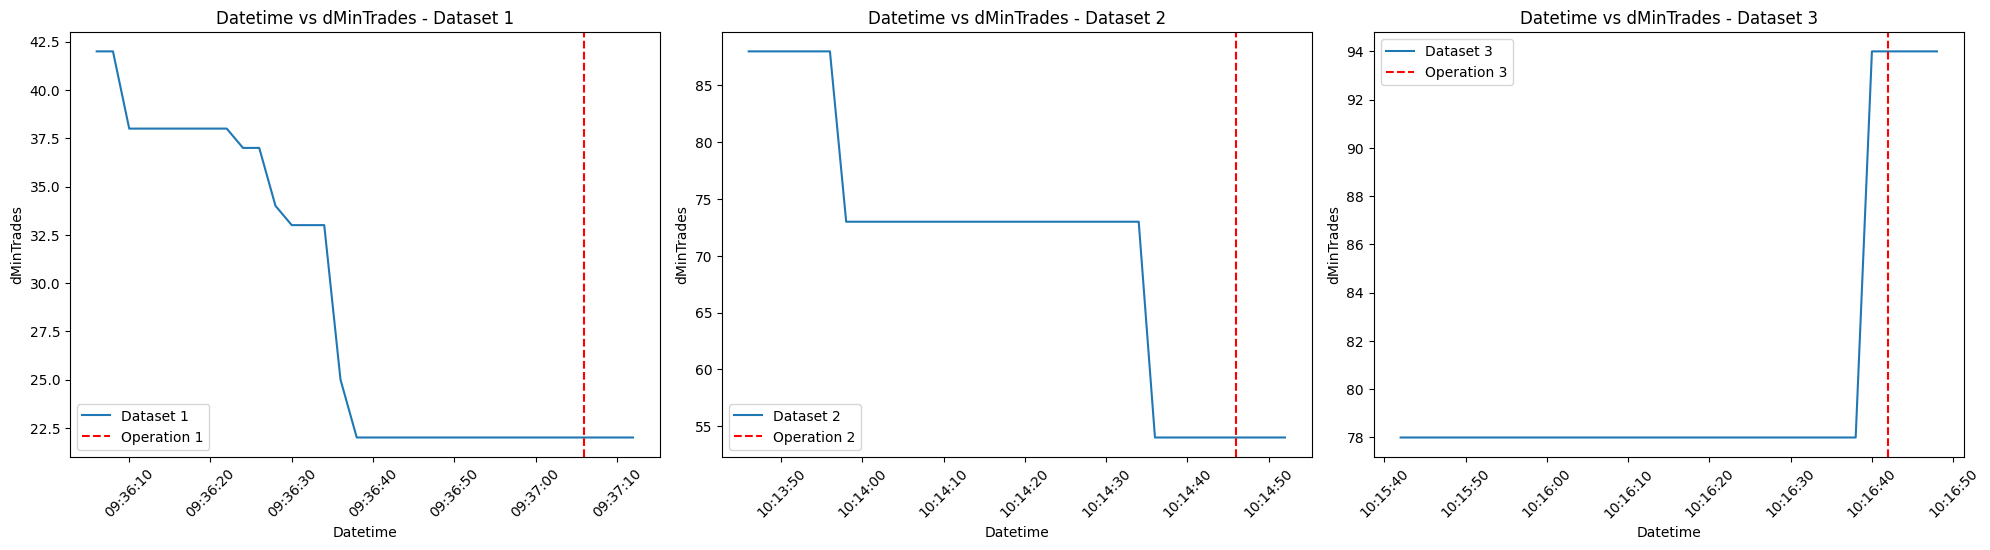

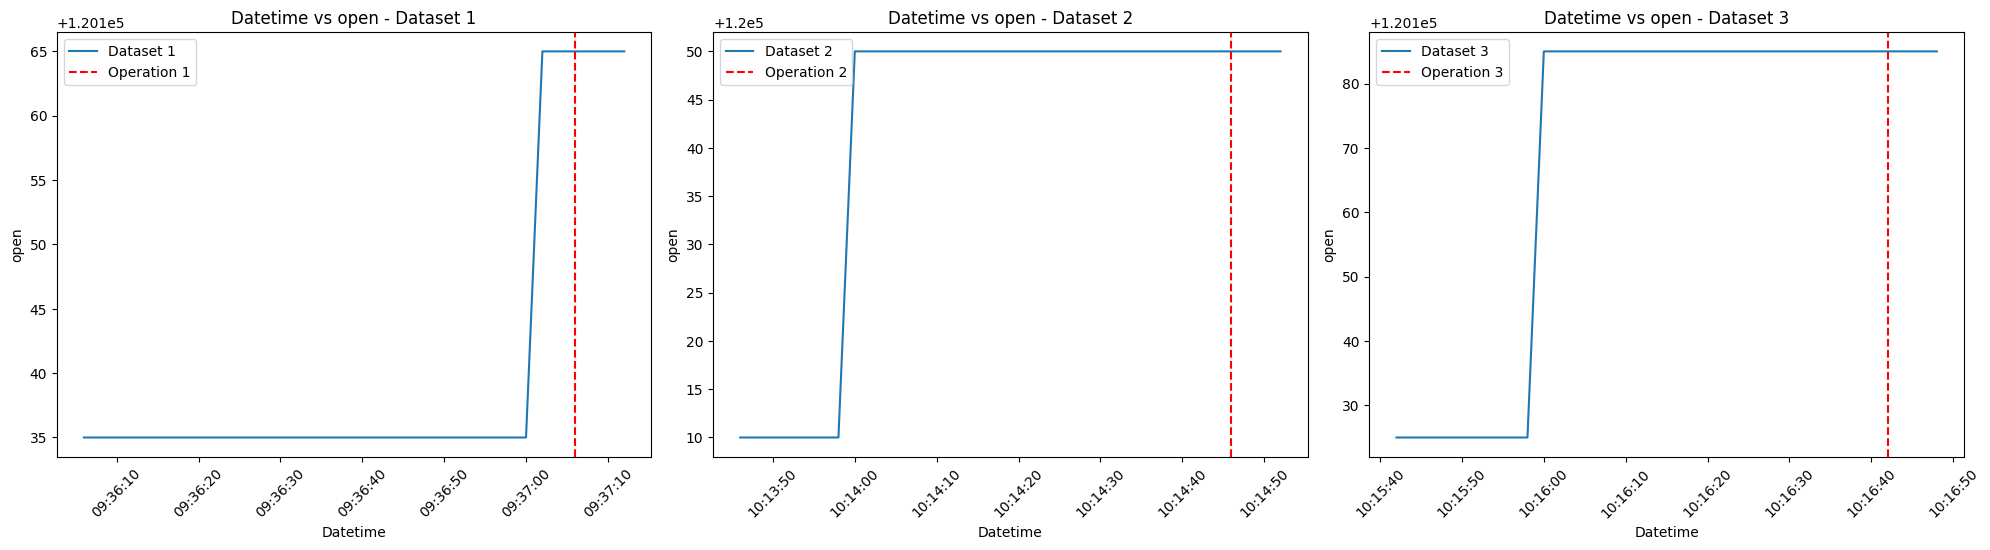

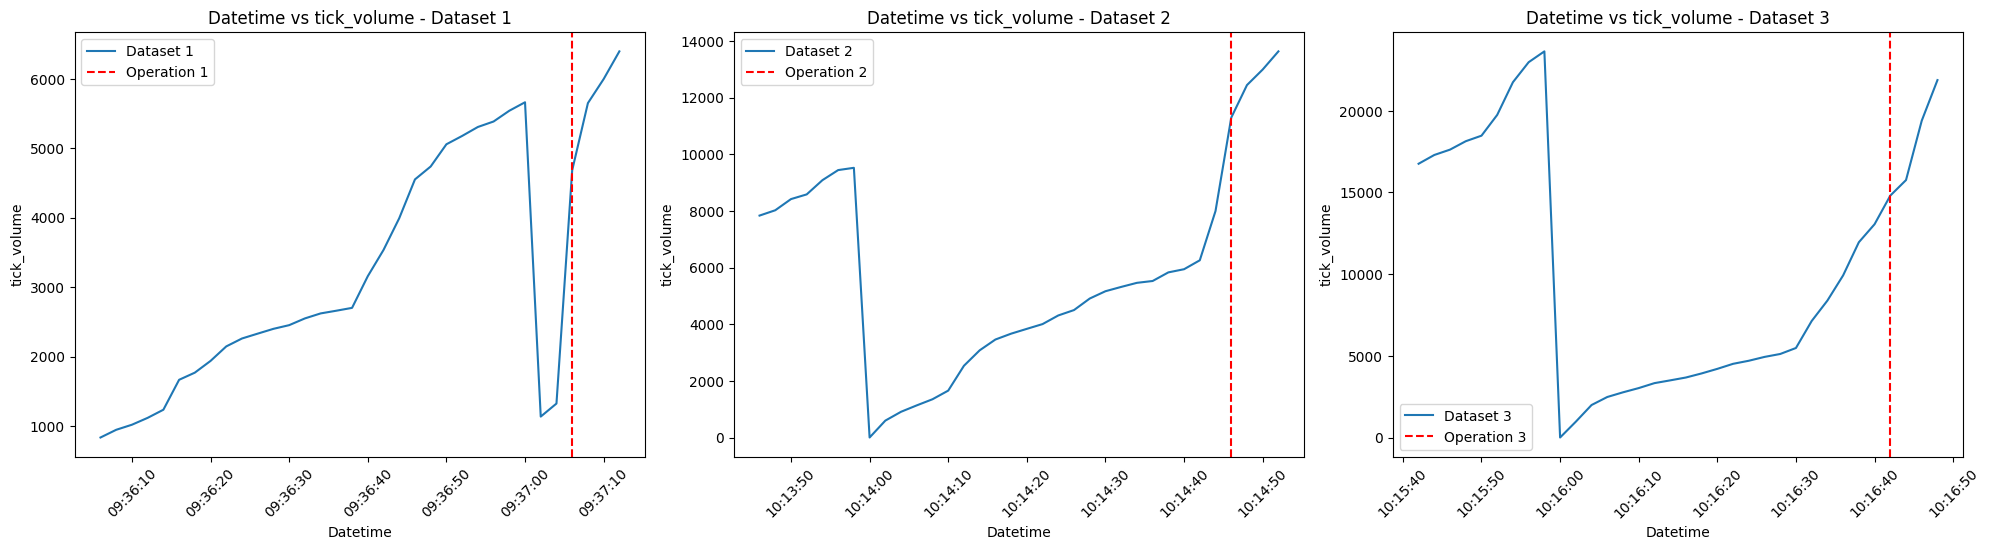

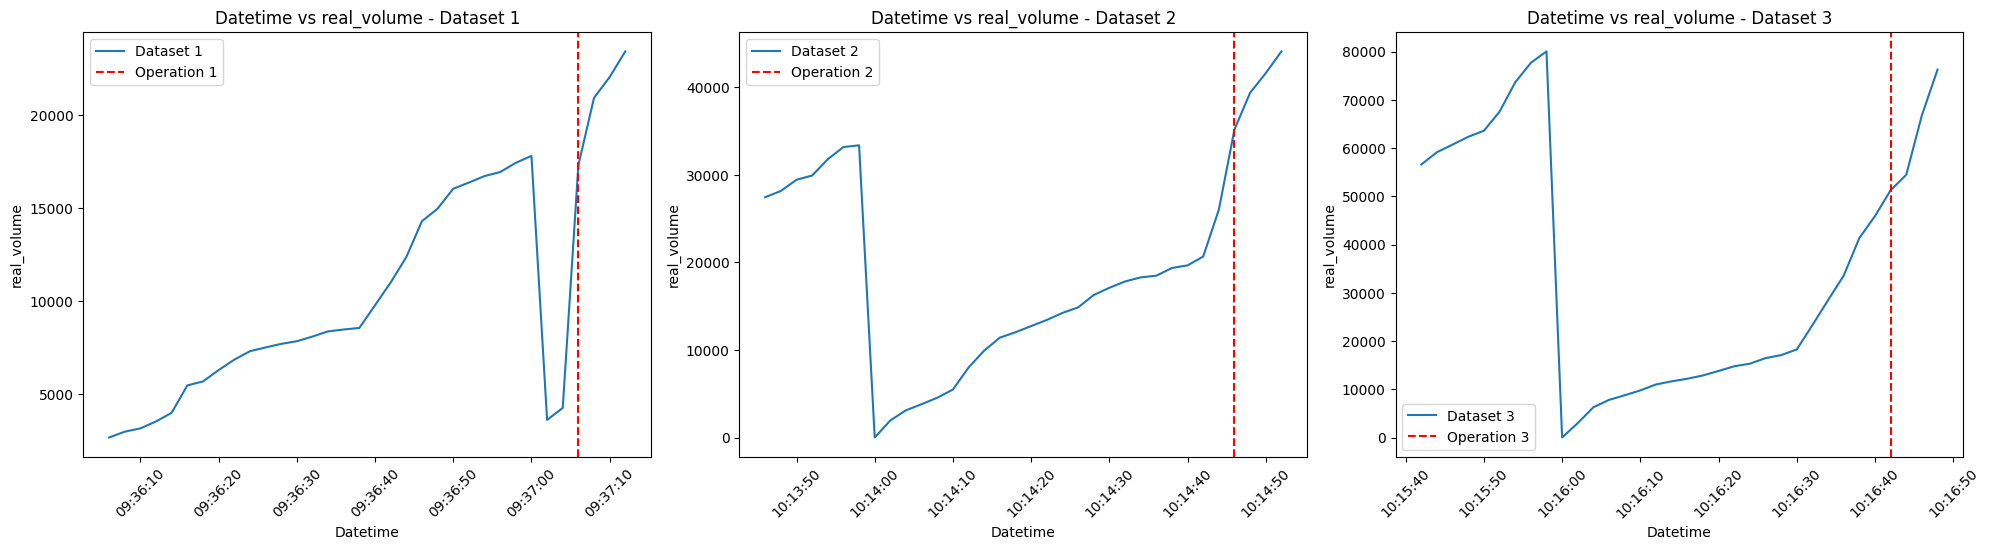

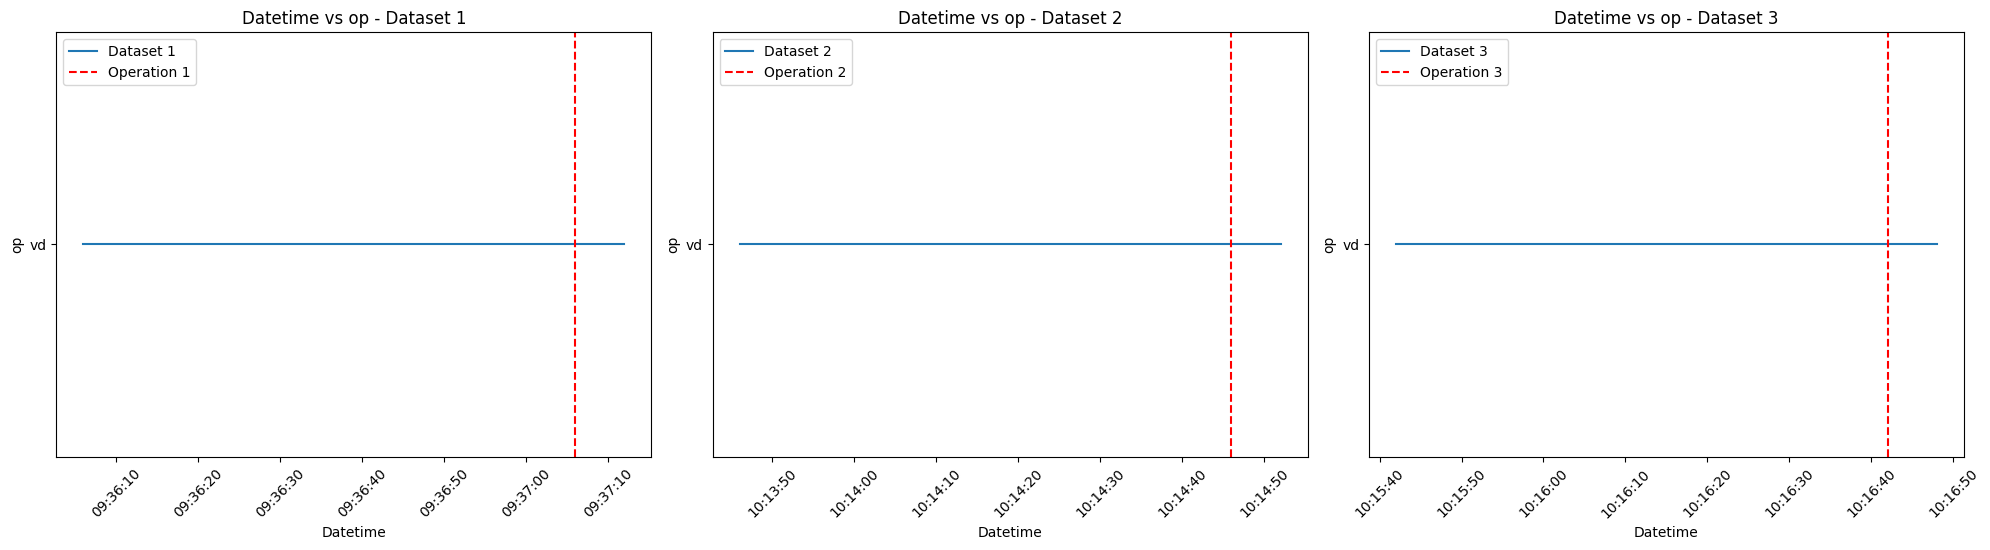

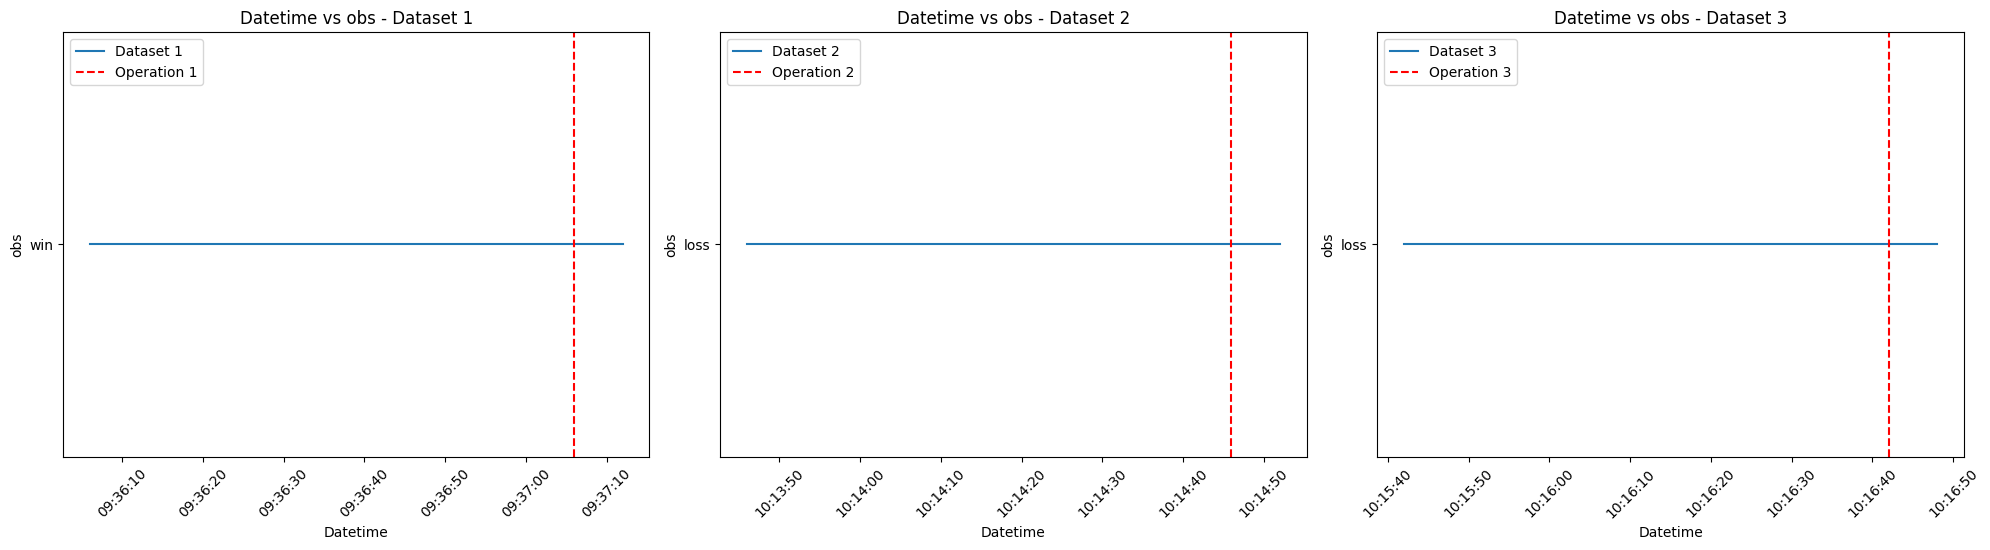

In [12]:
included_features = set(FEATURES[OPERATION_TYPES[0]]['included'])
excluded_features = set(FEATURES[OPERATION_TYPES[0]]['excluded'])

included_features.add('datetime')
excluded_features.discard('datetime')

sample_to_plot = [
    operations_dataframes[0],
    operations_dataframes[1],
    operations_dataframes[2],
]

columns_to_plot = sample_to_plot[0].columns.drop(excluded_features)
nrows, ncols = optimal_grid(len(sample_to_plot))

for column in columns_to_plot:
    plt.figure(figsize=optimal_figsize(ncols))

    for j, dataset in enumerate(sample_to_plot):
        plt.subplot(nrows, ncols, j + 1)

        x = np.array(dataset['dt'])
        y = np.array(dataset[column])

        plt.plot(x, y, label=f'Dataset {j+1}')
        plt.title(f'Datetime vs {column} - Dataset {j+1}')
        plt.xlabel('Datetime')
        plt.ylabel(column)
        plt.xticks(rotation=45)
        plt.axvline(x=operations_datetimes[j], color='red', linestyle='--', label=f'Operation {j+1}')

        plt.legend()
        plt.tight_layout()

    plt.show()

In [13]:
FEATURES[OPERATION_TYPES[0]]['included']

['dMaxDifPrecoCum',
 'real_volume',
 'dAmpDifPrecoCum',
 'dMinDifVolCum',
 'dMinTrades',
 'stdDev_buffer_1',
 'ampmedia',
 'dMinDifPrecoCum',
 'dVol',
 'tick_volume',
 'dMaxDifVolCum',
 'dMaxTrades',
 'open']

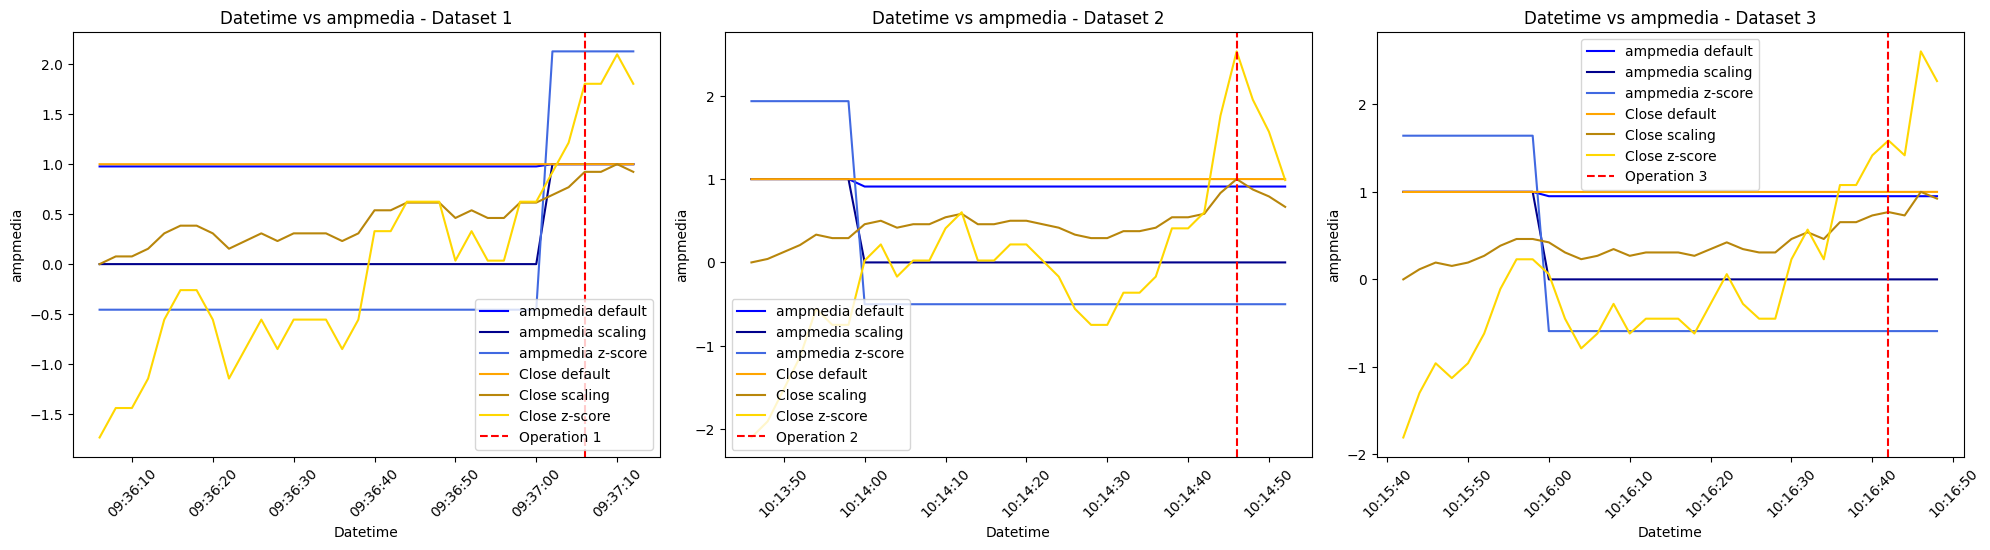

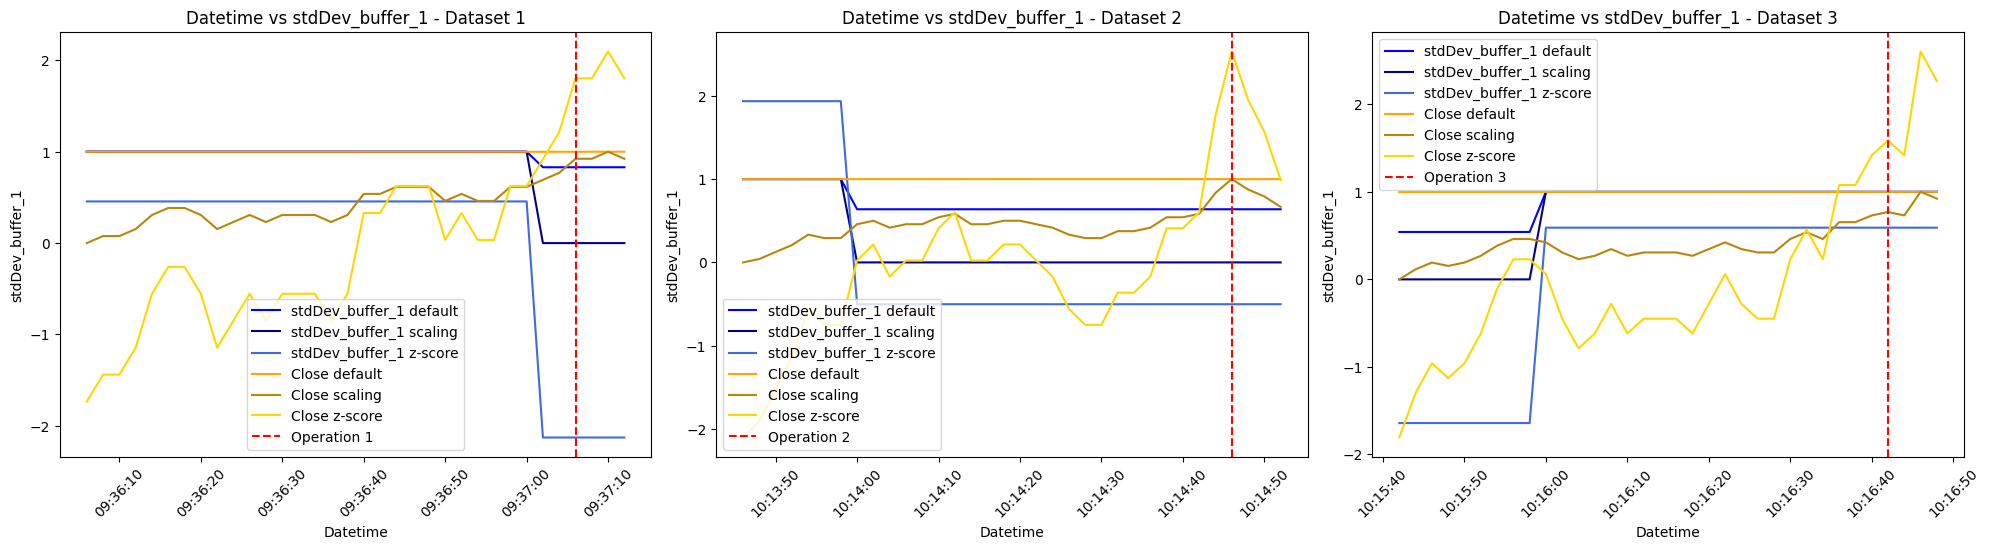

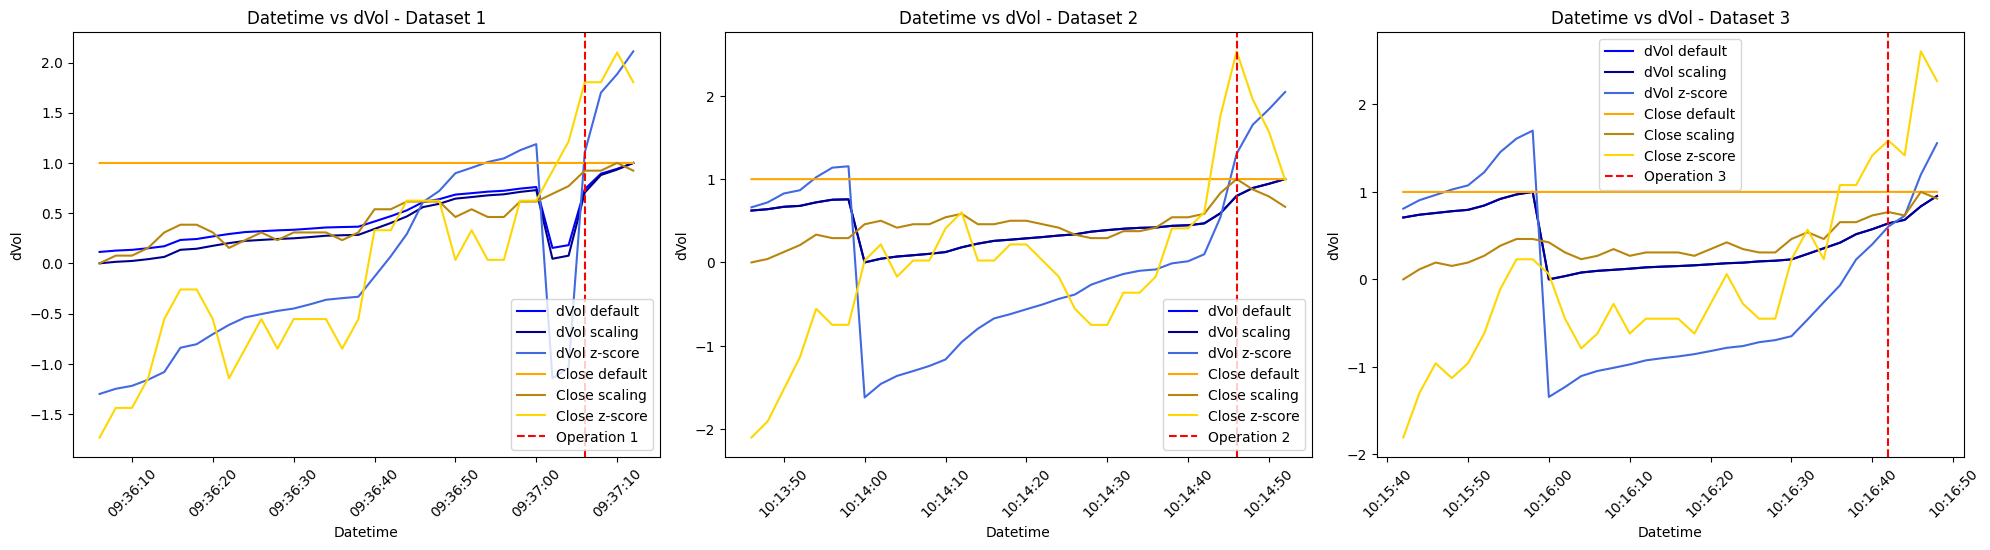

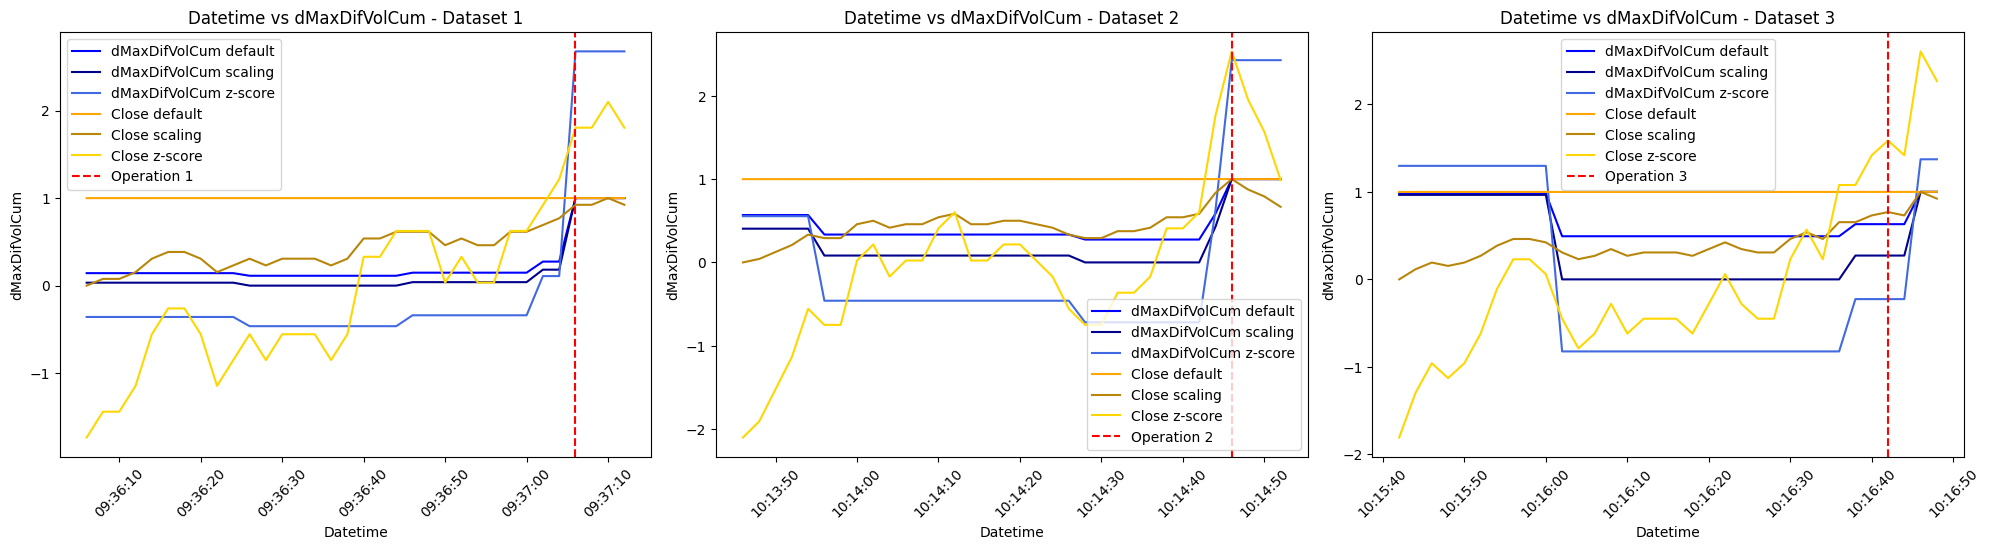

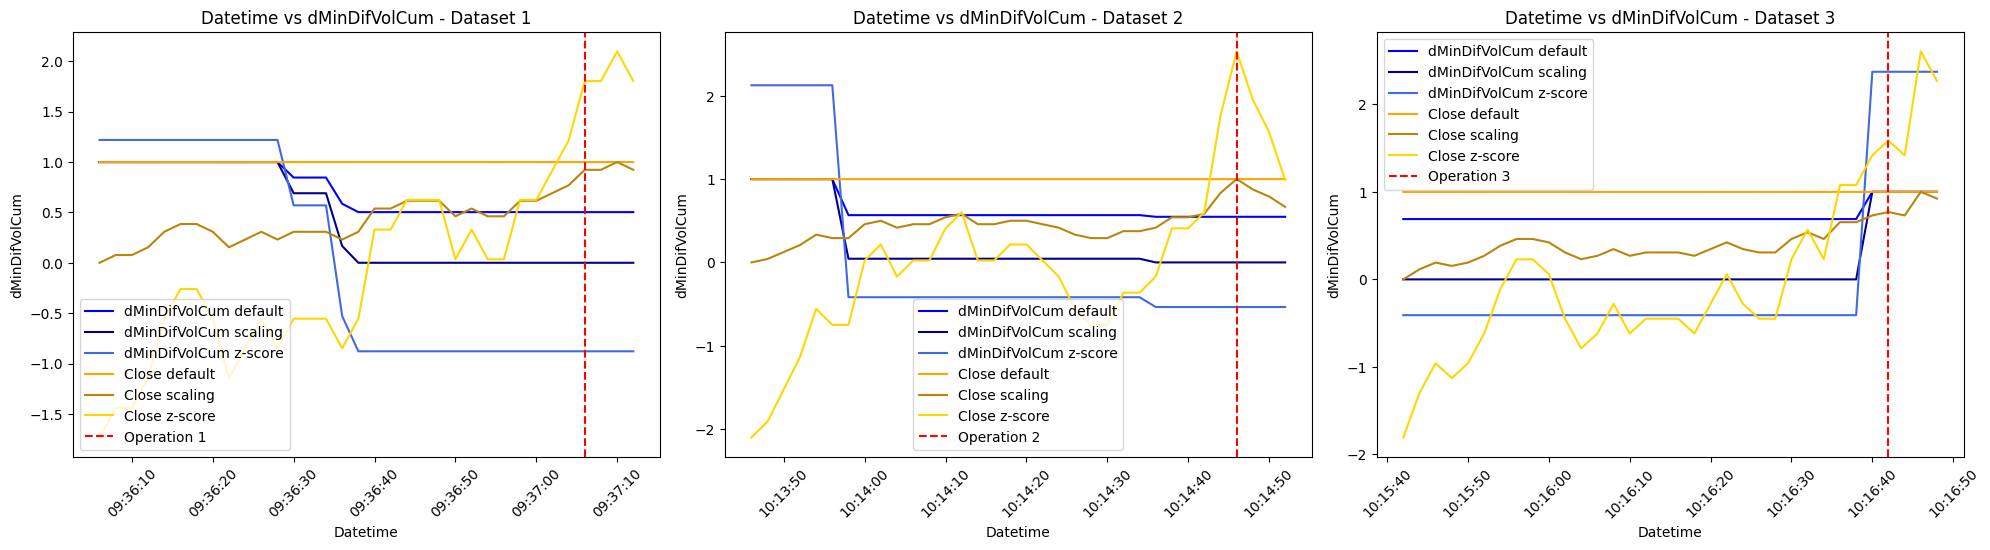

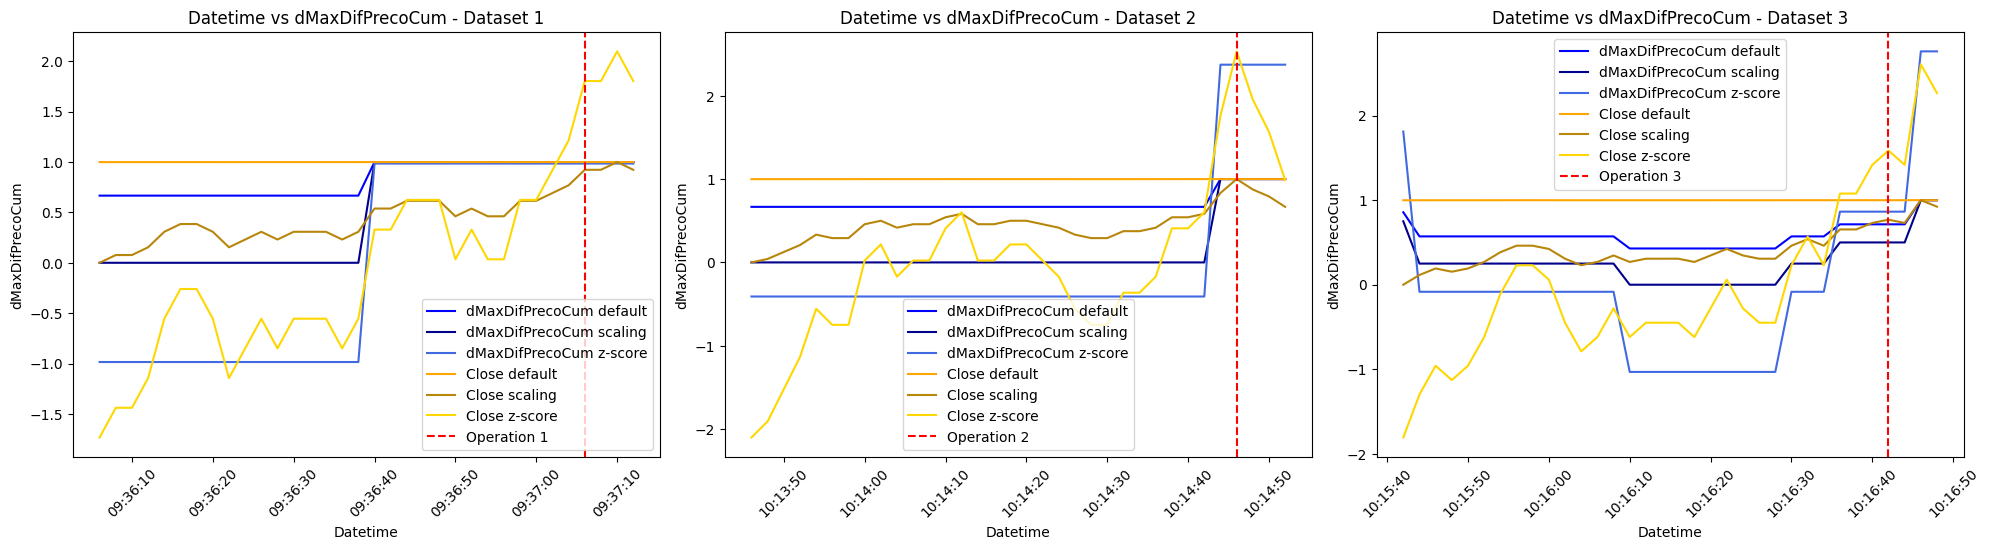

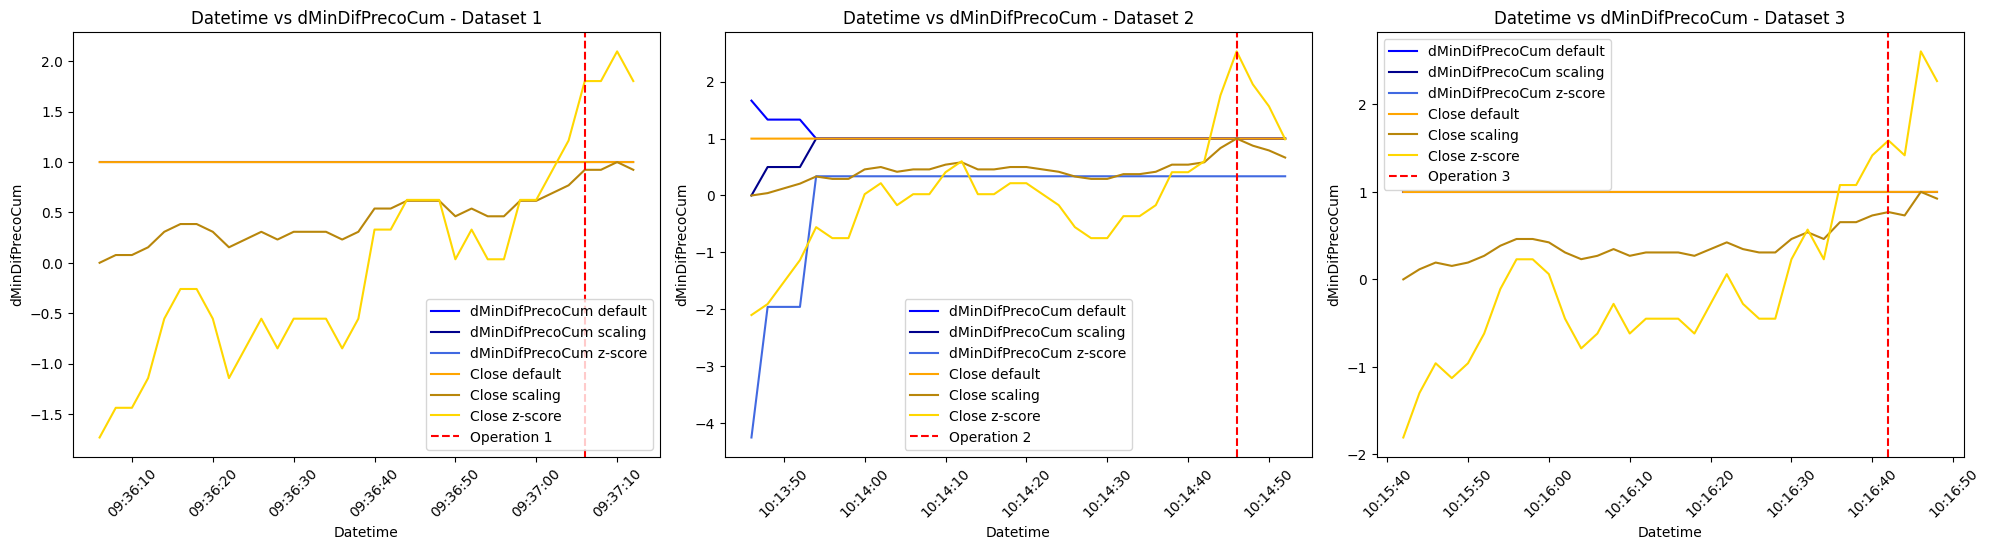

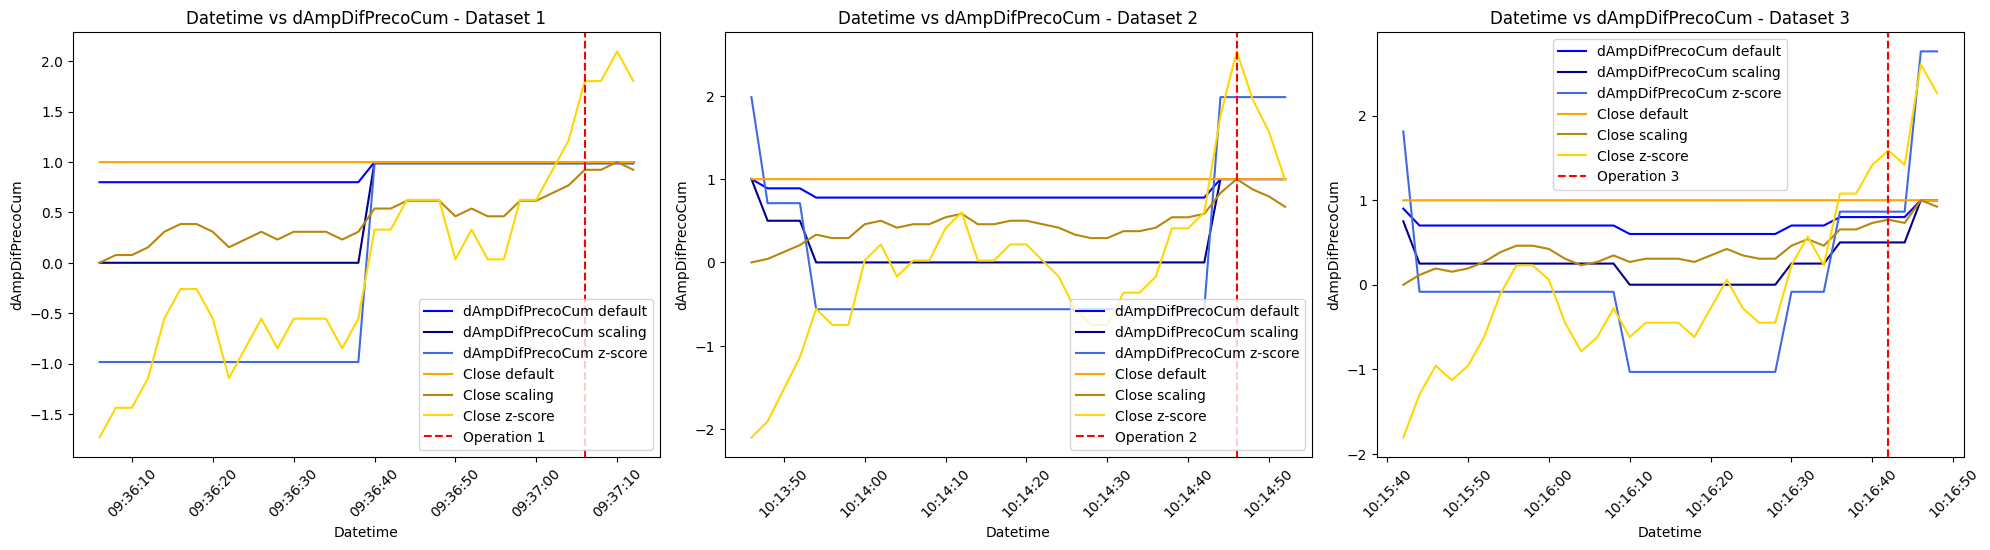

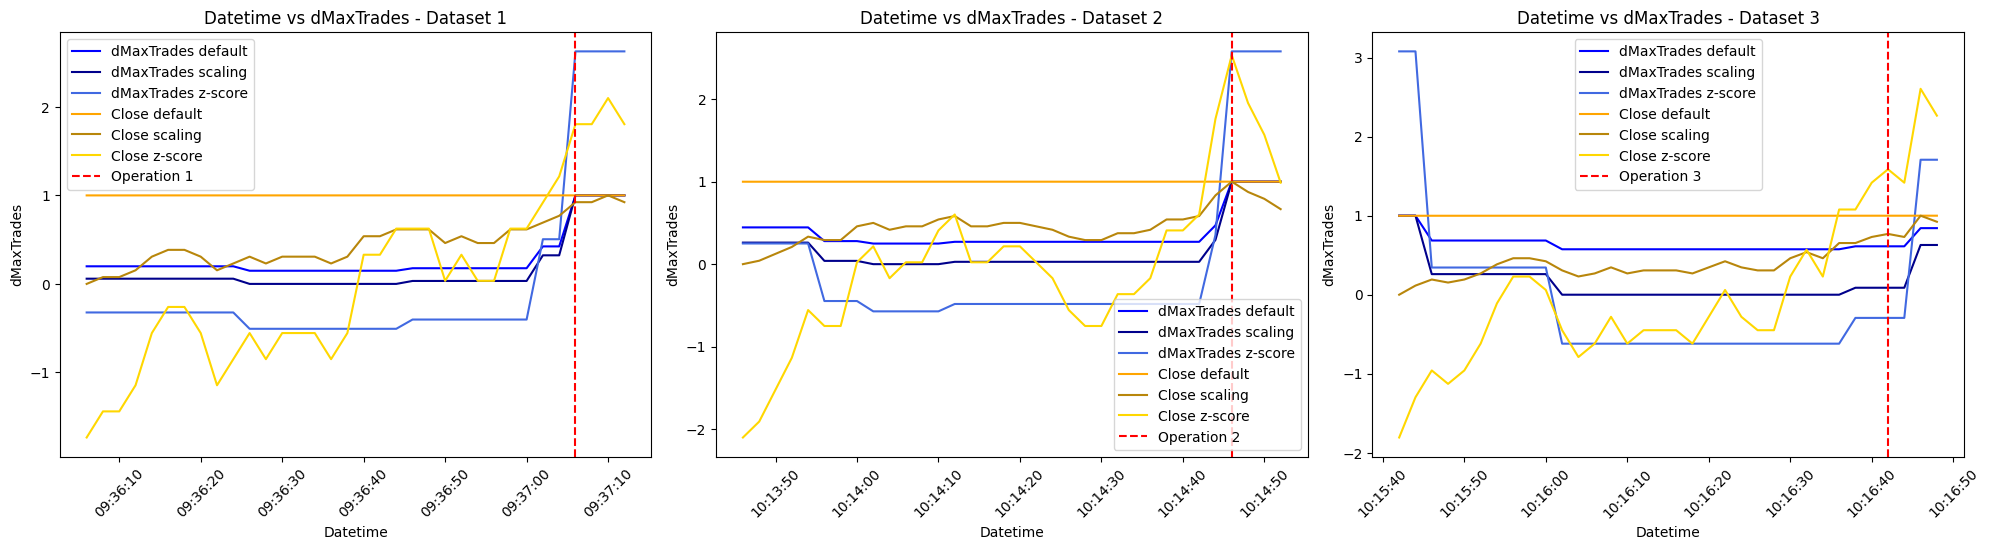

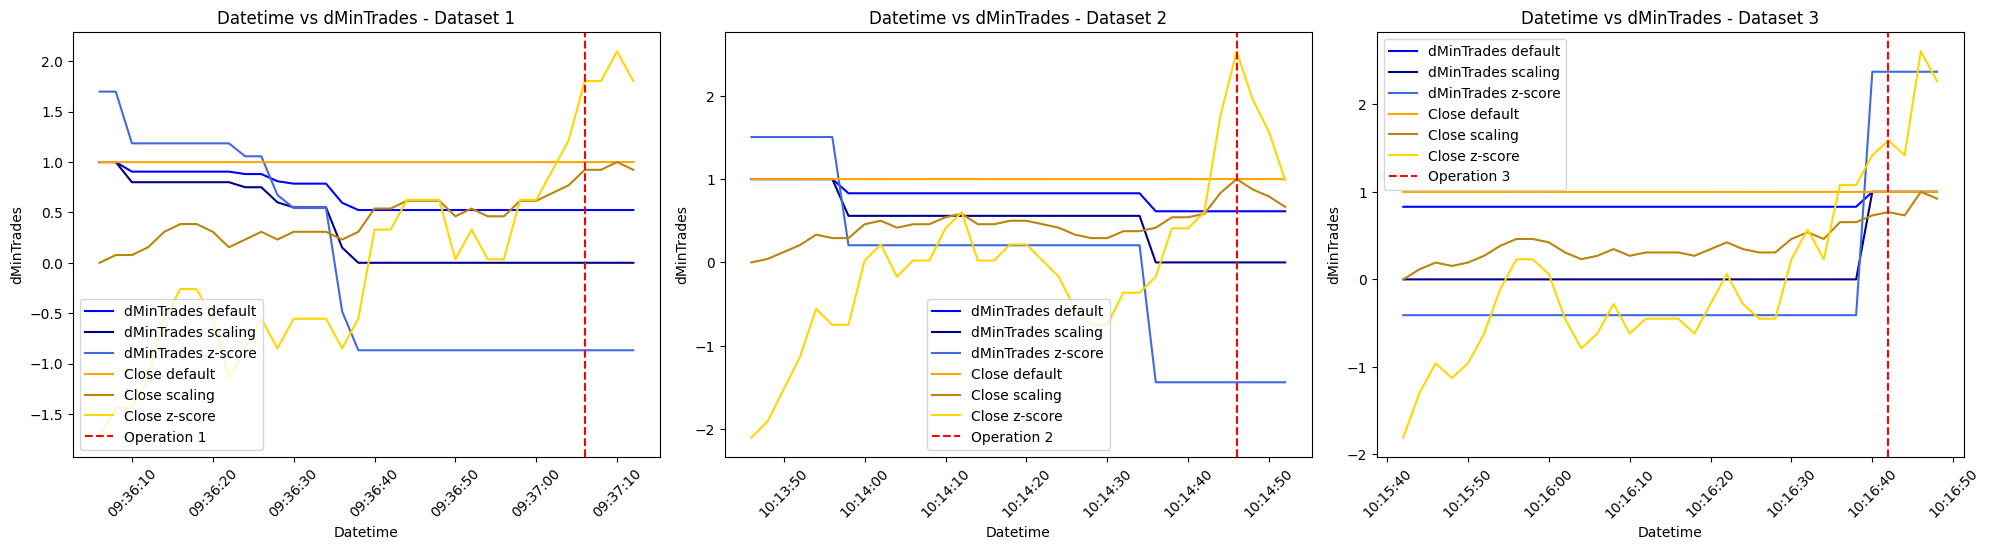

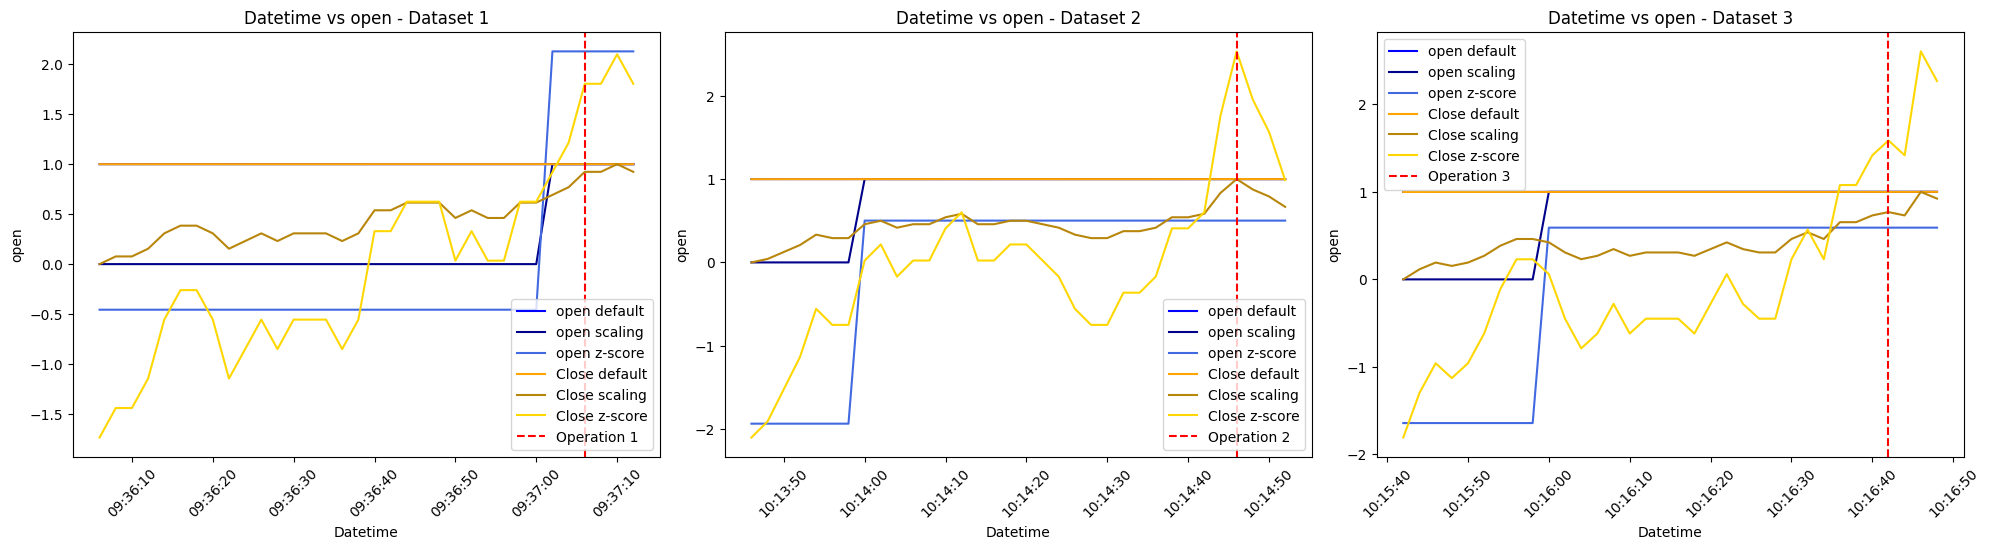

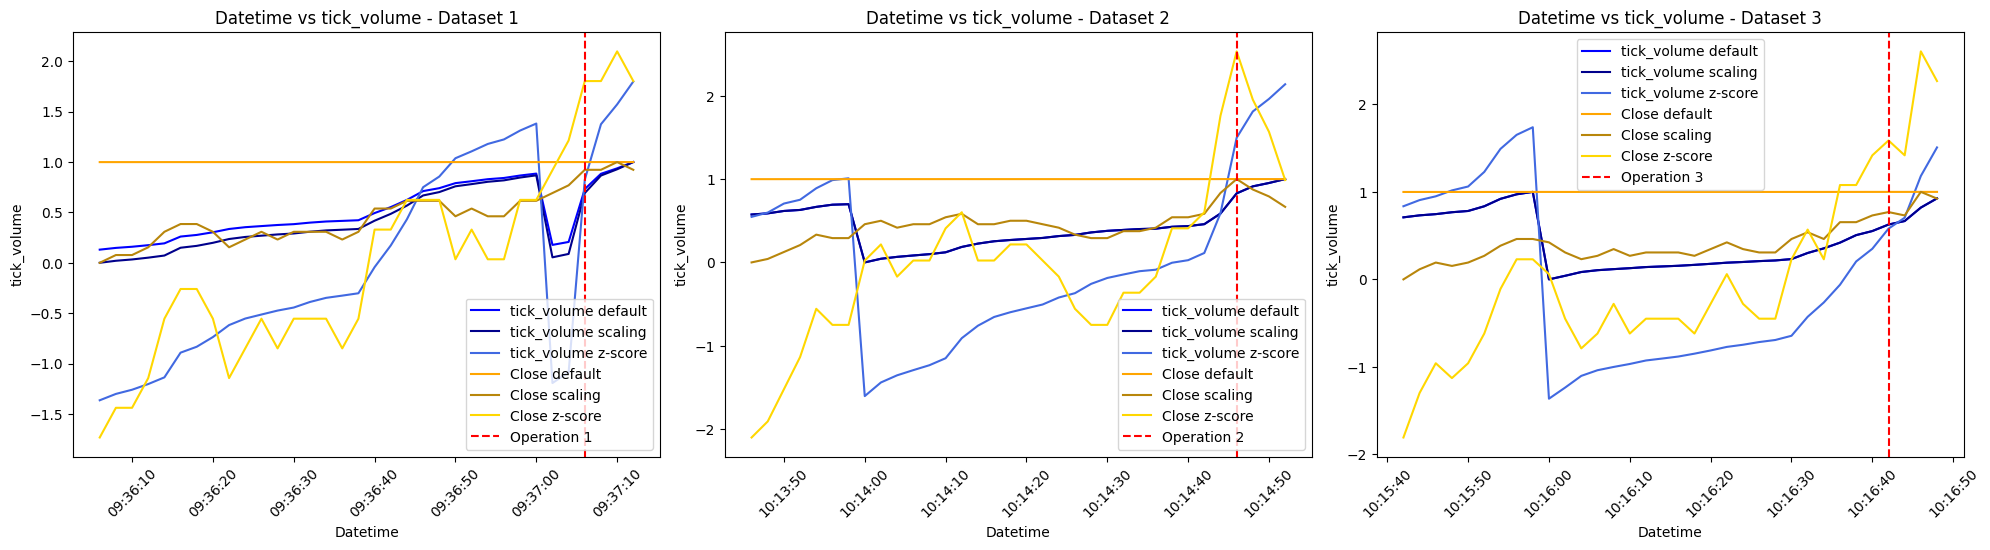

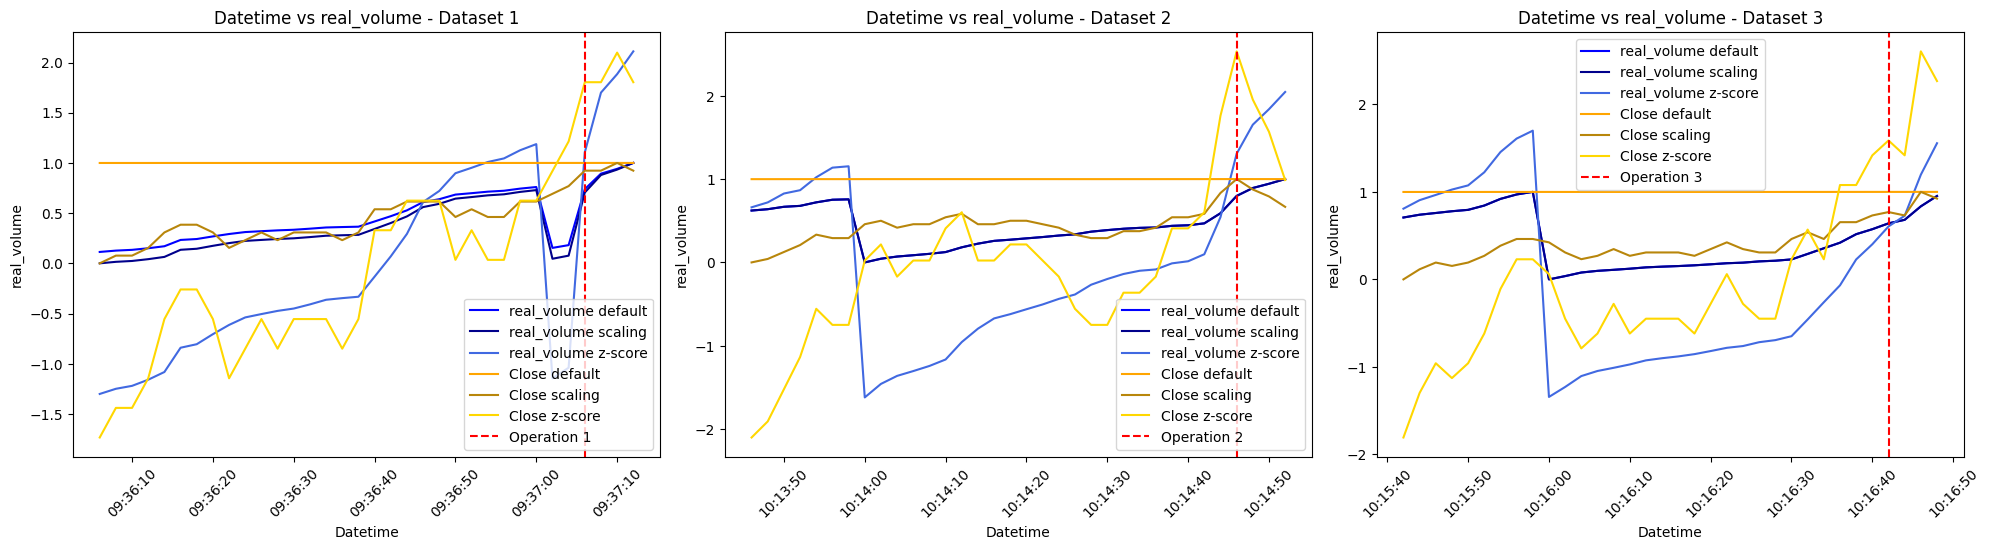

In [14]:
included_features = set(FEATURES[OPERATION_TYPES[0]]['included'])
excluded_features = set(FEATURES[OPERATION_TYPES[0]]['excluded'])

included_features.add('datetime')
excluded_features.discard('datetime')

included_features.discard('op')
included_features.discard('obs')
excluded_features.add('op')
excluded_features.add('obs')

sample_to_plot = [
    operations_dataframes[0],
    operations_dataframes[1],
    operations_dataframes[2],
]

columns_to_plot = sample_to_plot[0].columns.drop(excluded_features)
nrows, ncols = optimal_grid(len(sample_to_plot))

for column in columns_to_plot:
    plt.figure(figsize=optimal_figsize(ncols))

    for j, dataset in enumerate(sample_to_plot):
        plt.subplot(nrows, ncols, j + 1)

        x = np.array(dataset['dt'])
        feature_default_normalization = np.array(get_normalized_feature(dataframe = dataset, feature = column, normalization_type = None))
        feature_scaling_normalization = np.array(get_normalized_feature(dataframe = dataset, feature = column, normalization_type = 'SCALING'))
        feature_z_score_normalization = np.array(get_normalized_feature(dataframe = dataset, feature = column, normalization_type = 'Z-SCORE'))

        close_default_normalization = np.array(get_normalized_feature(dataframe = dataset, feature = 'close', normalization_type = None))
        close_scaling_normalization = np.array(get_normalized_feature(dataframe = dataset, feature = 'close', normalization_type = 'SCALING'))
        close_z_score_normalization = np.array(get_normalized_feature(dataframe = dataset, feature = 'close', normalization_type = 'Z-SCORE'))

        plt.plot(x, feature_default_normalization, label=f'{column} default', color = 'blue')
        plt.plot(x, feature_scaling_normalization, label=f'{column} scaling', color = 'darkblue')
        plt.plot(x, feature_z_score_normalization, label=f'{column} z-score', color = 'royalblue')

        plt.plot(x, close_default_normalization, label=f'Close default', color = 'orange')
        plt.plot(x, close_scaling_normalization, label=f'Close scaling', color = 'darkgoldenrod')
        plt.plot(x, close_z_score_normalization, label=f'Close z-score', color = 'gold')

        plt.title(f'Datetime vs {column} - Dataset {j+1}')
        plt.xlabel('Datetime')
        plt.ylabel(column)

        plt.xticks(rotation=45)
        plt.axvline(x=operations_datetimes[j], color='#FF0000', linestyle='--', label=f'Operation {j+1}')

        plt.legend()
        plt.tight_layout()

    plt.show()

In [15]:
threshold = 0.99
correlation_counts = {}

for operation_type in FEATURES:
    print(f'for operation: {operation_type}')
    dataframes = []
    for dataframe in operations_dataframes:
        condition = (dataframe['op'] == operation_type[0]) & (dataframe['obs'] == operation_type[1])
        if condition.any():
            dataframes.append(dataframe)

    for df in dataframes:
        dataframe = df.drop(excluded_features, axis=1)
        correlated_pairs = find_highly_correlated_pairs(dataframe, threshold)

        for pair in correlated_pairs:
            for feature in pair:
                if feature not in correlation_counts:
                    correlation_counts[feature] = {}

                other_feature = pair[1] if feature == pair[0] else pair[0]
                correlation_counts[feature][other_feature] = correlation_counts[feature].get(other_feature, 0) + 1

    for feature, correlations in correlation_counts.items():
        print(f"{feature}: ")
        for correlated_feature, count in correlations.items():
            print(f"    {correlated_feature}: {count} occurrences")
        print()

for operation: ('vd', 'win')
stdDev_buffer_1: 
    ampmedia: 150 occurrences
    open: 147 occurrences
    dMinDifPrecoCum: 3 occurrences
    dAmpDifPrecoCum: 2 occurrences
    dMinDifVolCum: 1 occurrences
    dMaxDifPrecoCum: 3 occurrences

ampmedia: 
    stdDev_buffer_1: 150 occurrences
    open: 143 occurrences
    dMinDifPrecoCum: 3 occurrences
    dAmpDifPrecoCum: 2 occurrences
    dMinDifVolCum: 1 occurrences
    dMaxDifPrecoCum: 3 occurrences

dAmpDifPrecoCum: 
    dMaxDifPrecoCum: 34 occurrences
    ampmedia: 2 occurrences
    stdDev_buffer_1: 2 occurrences
    dMinDifPrecoCum: 13 occurrences
    open: 2 occurrences
    dMaxDifVolCum: 2 occurrences
    dMaxTrades: 1 occurrences

dMaxDifPrecoCum: 
    dAmpDifPrecoCum: 34 occurrences
    dMaxDifVolCum: 6 occurrences
    dMaxTrades: 2 occurrences
    ampmedia: 3 occurrences
    stdDev_buffer_1: 3 occurrences
    open: 2 occurrences
    dMinDifVolCum: 2 occurrences
    dMinTrades: 1 occurrences

dMaxTrades: 
    dMaxDifVolCum: 39 o

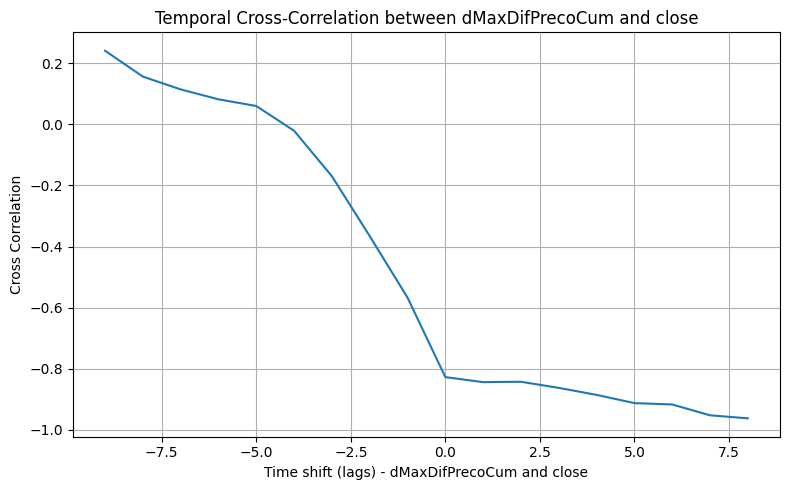

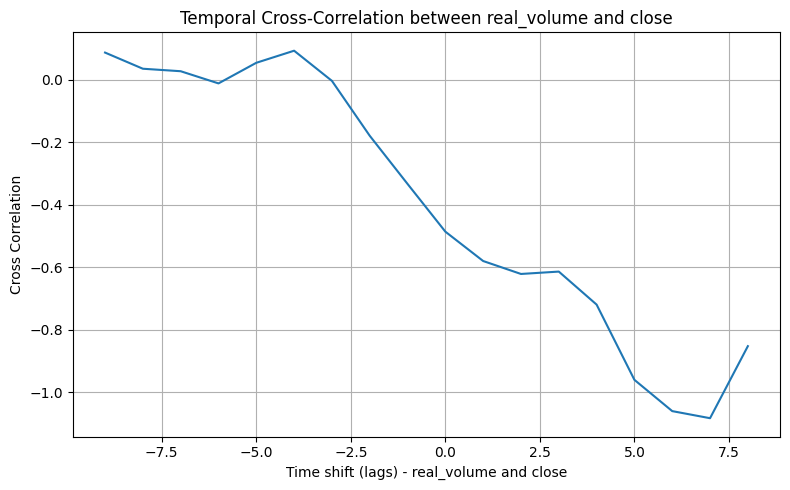

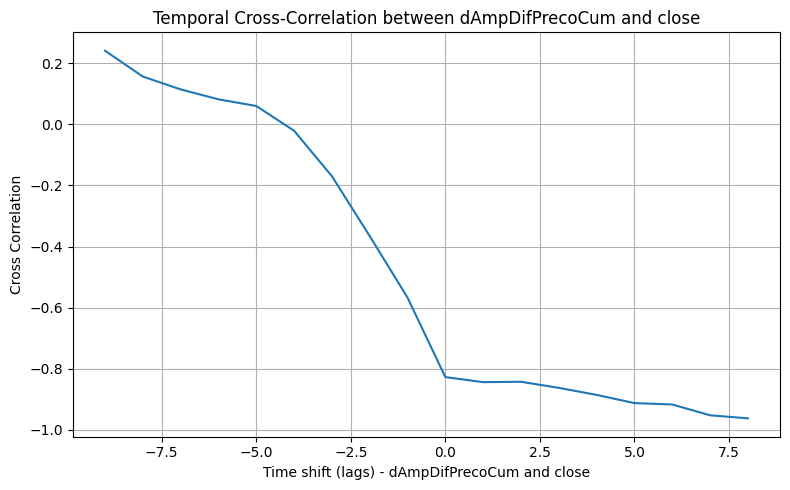

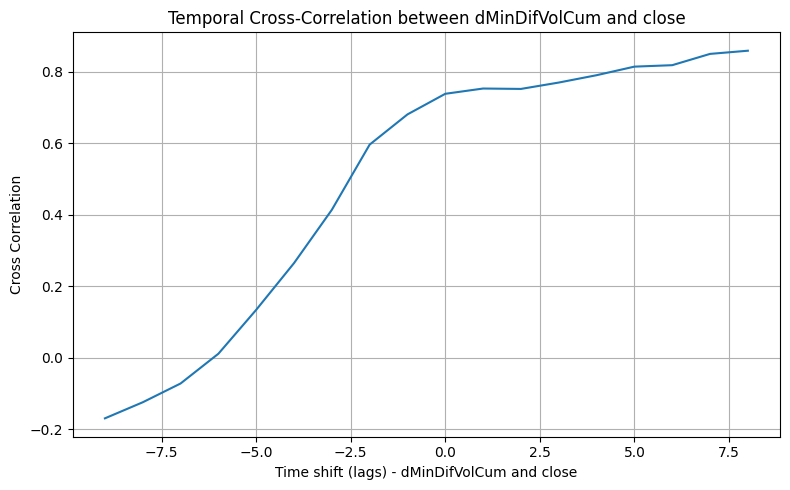

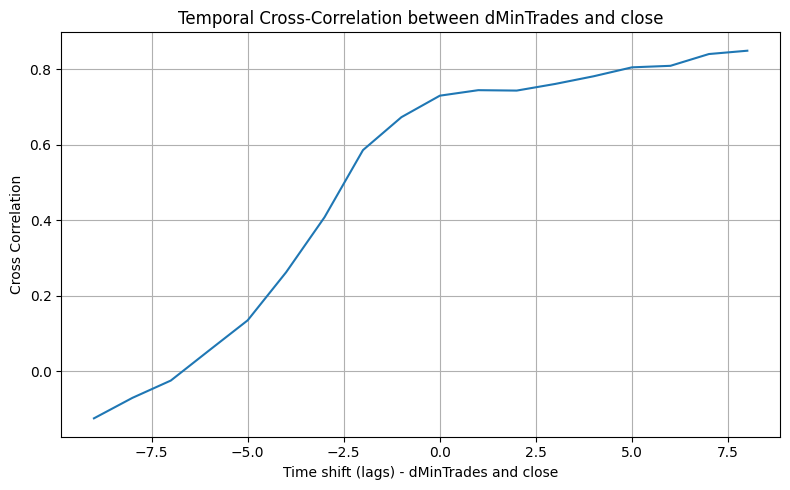

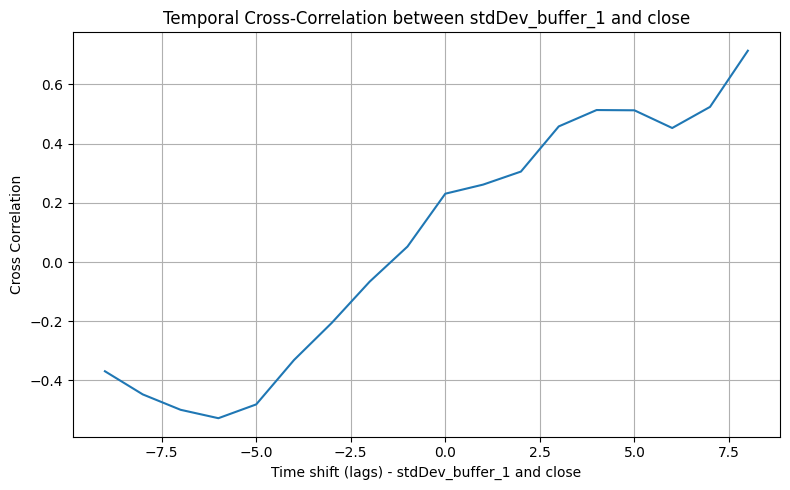

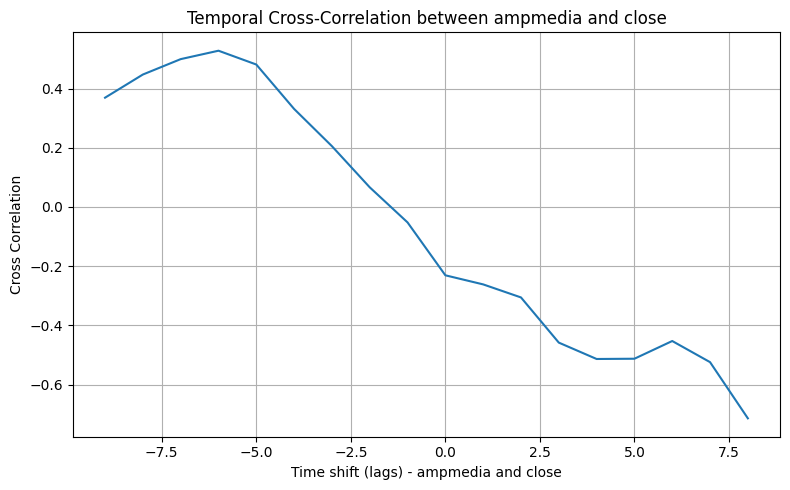

/home/mdlw/miniconda3/envs/mdlw/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1179: RuntimeWarning: invalid value encountered in divide
  ret = cvf / (np.std(x) * np.std(y))


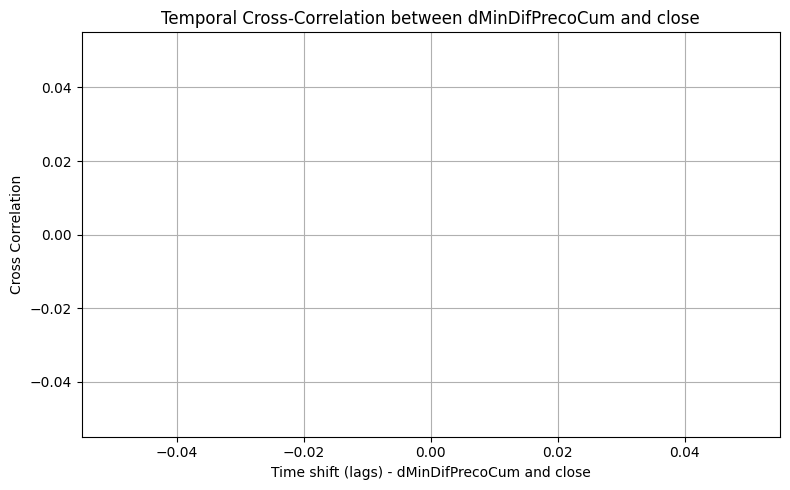

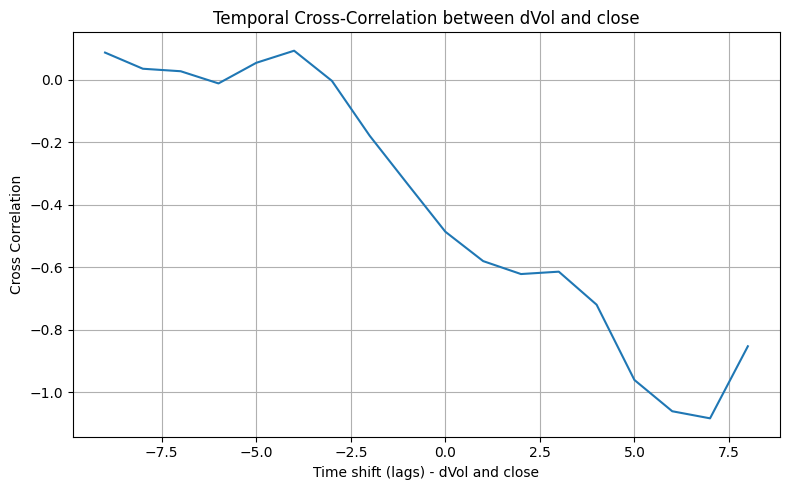

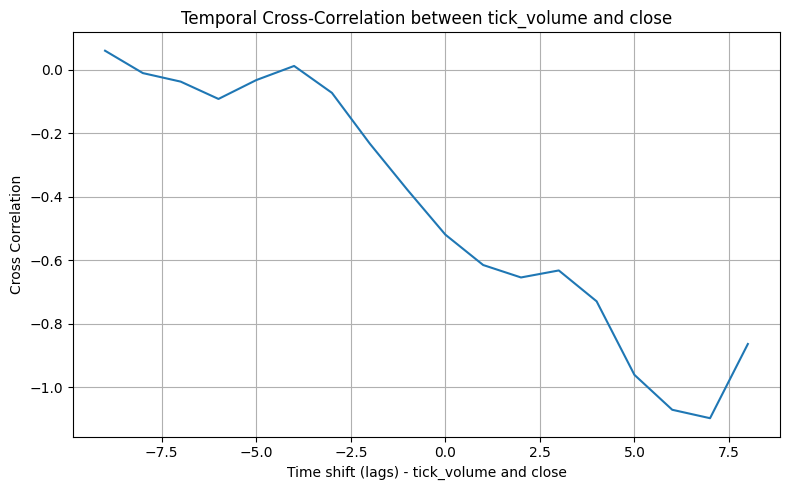

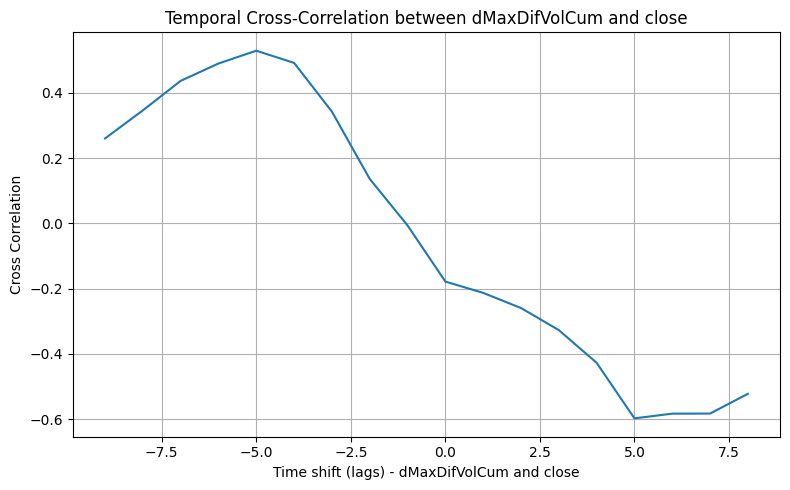

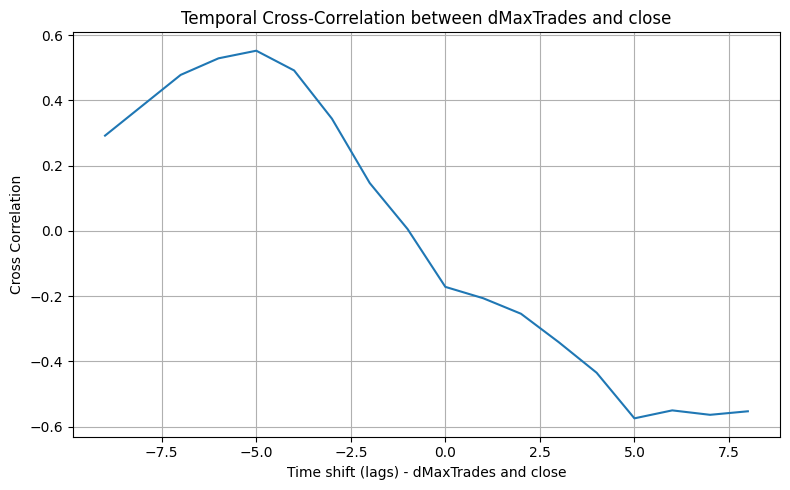

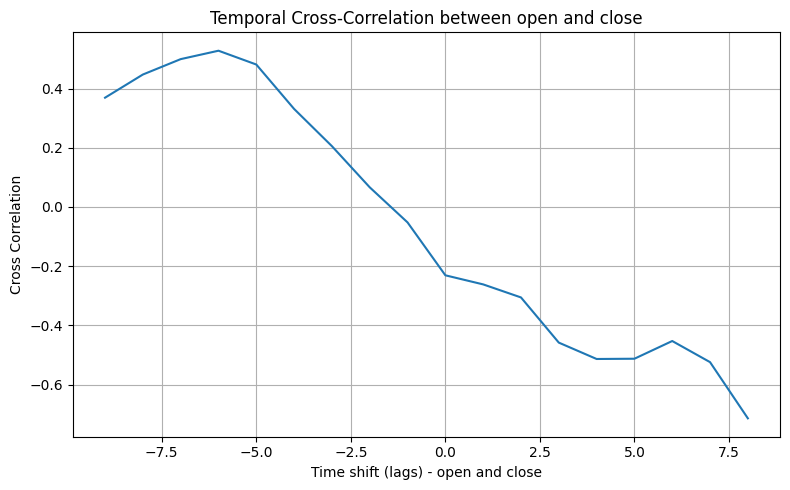

In [16]:
features_list = FEATURES[OPERATION_TYPES[0]]['included']

dataframes = []
for dataframe in operations_dataframes:
    condition = (dataframe['op'] == OPERATION_TYPES[0][0]) & (dataframe['obs'] == OPERATION_TYPES[0][1])
    if not condition.any():
        continue

for i in range(len(features_list)):

    feature1 = operations_dataframes[0][features_list[i]]
    feature2 = operations_dataframes[0]['close']

    correlation_values = ccf(feature1, feature2)

    lags = range(-9, 9)
    correlation_values = correlation_values[len(correlation_values)//2 - 9: len(correlation_values)//2 + 9]

    plt.figure(figsize=(8, 5))
    plt.plot(lags, correlation_values)
    plt.xlabel(f'Time shift (lags) - {features_list[i]} and close')
    plt.ylabel('Cross Correlation')
    plt.title(f'Temporal Cross-Correlation between {features_list[i]} and close')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## Defining model

In [17]:
dataframes = {
    operation_type: {
        'included': FEATURES[operation_type]['included'],
        'excluded': not_interesting
    } for operation_type in OPERATION_TYPES
}

dataframes

{('vd',
  'win'): {'included': ['dMaxDifPrecoCum',
   'real_volume',
   'dAmpDifPrecoCum',
   'dMinDifVolCum',
   'dMinTrades',
   'stdDev_buffer_1',
   'ampmedia',
   'dMinDifPrecoCum',
   'dVol',
   'tick_volume',
   'dMaxDifVolCum',
   'dMaxTrades',
   'open'], 'excluded': ['id',
   'decisao',
   'tp',
   'sl',
   'datetime',
   'dt',
   'hour',
   'minute',
   'second']},
 ('vd',
  'loss'): {'included': ['dMaxDifPrecoCum',
   'real_volume',
   'dMinDifVolCum',
   'dMinTrades',
   'stdDev_buffer_1',
   'ampmedia',
   'dMinDifPrecoCum',
   'dVol',
   'tick_volume',
   'open',
   'dMedOfMedDifPrecoCum'], 'excluded': ['id',
   'decisao',
   'tp',
   'sl',
   'datetime',
   'dt',
   'hour',
   'minute',
   'second']},
 ('cp',
  'win'): {'included': ['dMedDifPrecoCum',
   'dMaxDifPrecoCum',
   'real_volume',
   'dAmpDifPrecoCum',
   'dMinDifVolCum',
   'dMinTrades',
   'stdDev_buffer_1',
   'high',
   'ampmedia',
   'dMinDifPrecoCum',
   'dVol',
   'tick_volume',
   'open',
   'dMedOfMed

In [18]:
operation_type_dataframes = {}

for operation_type in FEATURES:
    filtered_dataframes = [
        df.drop(['op', 'obs'], axis=1)
        for df in operations_dataframes
        if ((df['op'] == operation_type[0]) & (df['obs'] == operation_type[1])).any()
    ]
    operation_type_dataframes[operation_type] = filtered_dataframes

In [19]:
max_correlations = {}

for operation_type in OPERATION_TYPES:
    max_correlations[operation_type] = {}
    features_list = FEATURES[operation_type]['included']


    for feature in features_list:
        feature1 = operation_type_dataframes[operation_type][0][feature]
        feature2 = operation_type_dataframes[operation_type][0]['close']

        if feature1.std() == 0 or feature2.std() == 0:
            # print(f"Skipping {feature} due to constant series.")
            continue

        correlation_values = ccf(feature1, feature2)

        desired_lags = -10
        start_index = max(0, len(correlation_values) // 2 + desired_lags)
        end_index = len(correlation_values) // 2 -1

        correlation_values = correlation_values[start_index:end_index]

        max_corr_index = np.argmax(np.abs(correlation_values))
        max_corr_lag = list(lags)[max_corr_index]
        max_correlations[operation_type][feature] = (max_corr_lag, correlation_values[max_corr_index])

for feature in max_correlations:
    print(f'{feature}: {max_correlations[feature]}')

('vd', 'win'): {'dMaxDifPrecoCum': (-1, np.float64(-0.3660254752089076)), 'real_volume': (-9, np.float64(0.22232802643954108)), 'dAmpDifPrecoCum': (-1, np.float64(-0.3660254752089076)), 'dMinDifVolCum': (-1, np.float64(0.5960457877676439)), 'dMinTrades': (-1, np.float64(0.5854182010577066)), 'stdDev_buffer_1': (-5, np.float64(-0.5278684334067131)), 'ampmedia': (-5, np.float64(0.5278684334067232)), 'dVol': (-9, np.float64(0.22232802643954108)), 'tick_volume': (-1, np.float64(-0.23247380583818222)), 'dMaxDifVolCum': (-4, np.float64(0.5289598034376982)), 'dMaxTrades': (-4, np.float64(0.5524901084271502)), 'open': (-5, np.float64(0.5278684334069002))}
('vd', 'loss'): {'dMaxDifPrecoCum': (-1, np.float64(0.23280237599238993)), 'real_volume': (-9, np.float64(0.39769134201452544)), 'dMinDifVolCum': (-7, np.float64(0.18508164778275604)), 'dMinTrades': (-1, np.float64(-0.2180638658854559)), 'stdDev_buffer_1': (-5, np.float64(0.20949395751048938)), 'ampmedia': (-5, np.float64(0.20949395751048866)

In [20]:
for operation_type in OPERATION_TYPES:
    for dataframe in operation_type_dataframes[operation_type]:
        value = 0
        for feature in list(max_correlations[operation_type].keys()):
            value = value + dataframe[feature] * max_correlations[operation_type][feature][1]

        dataframe['measurement'] = value

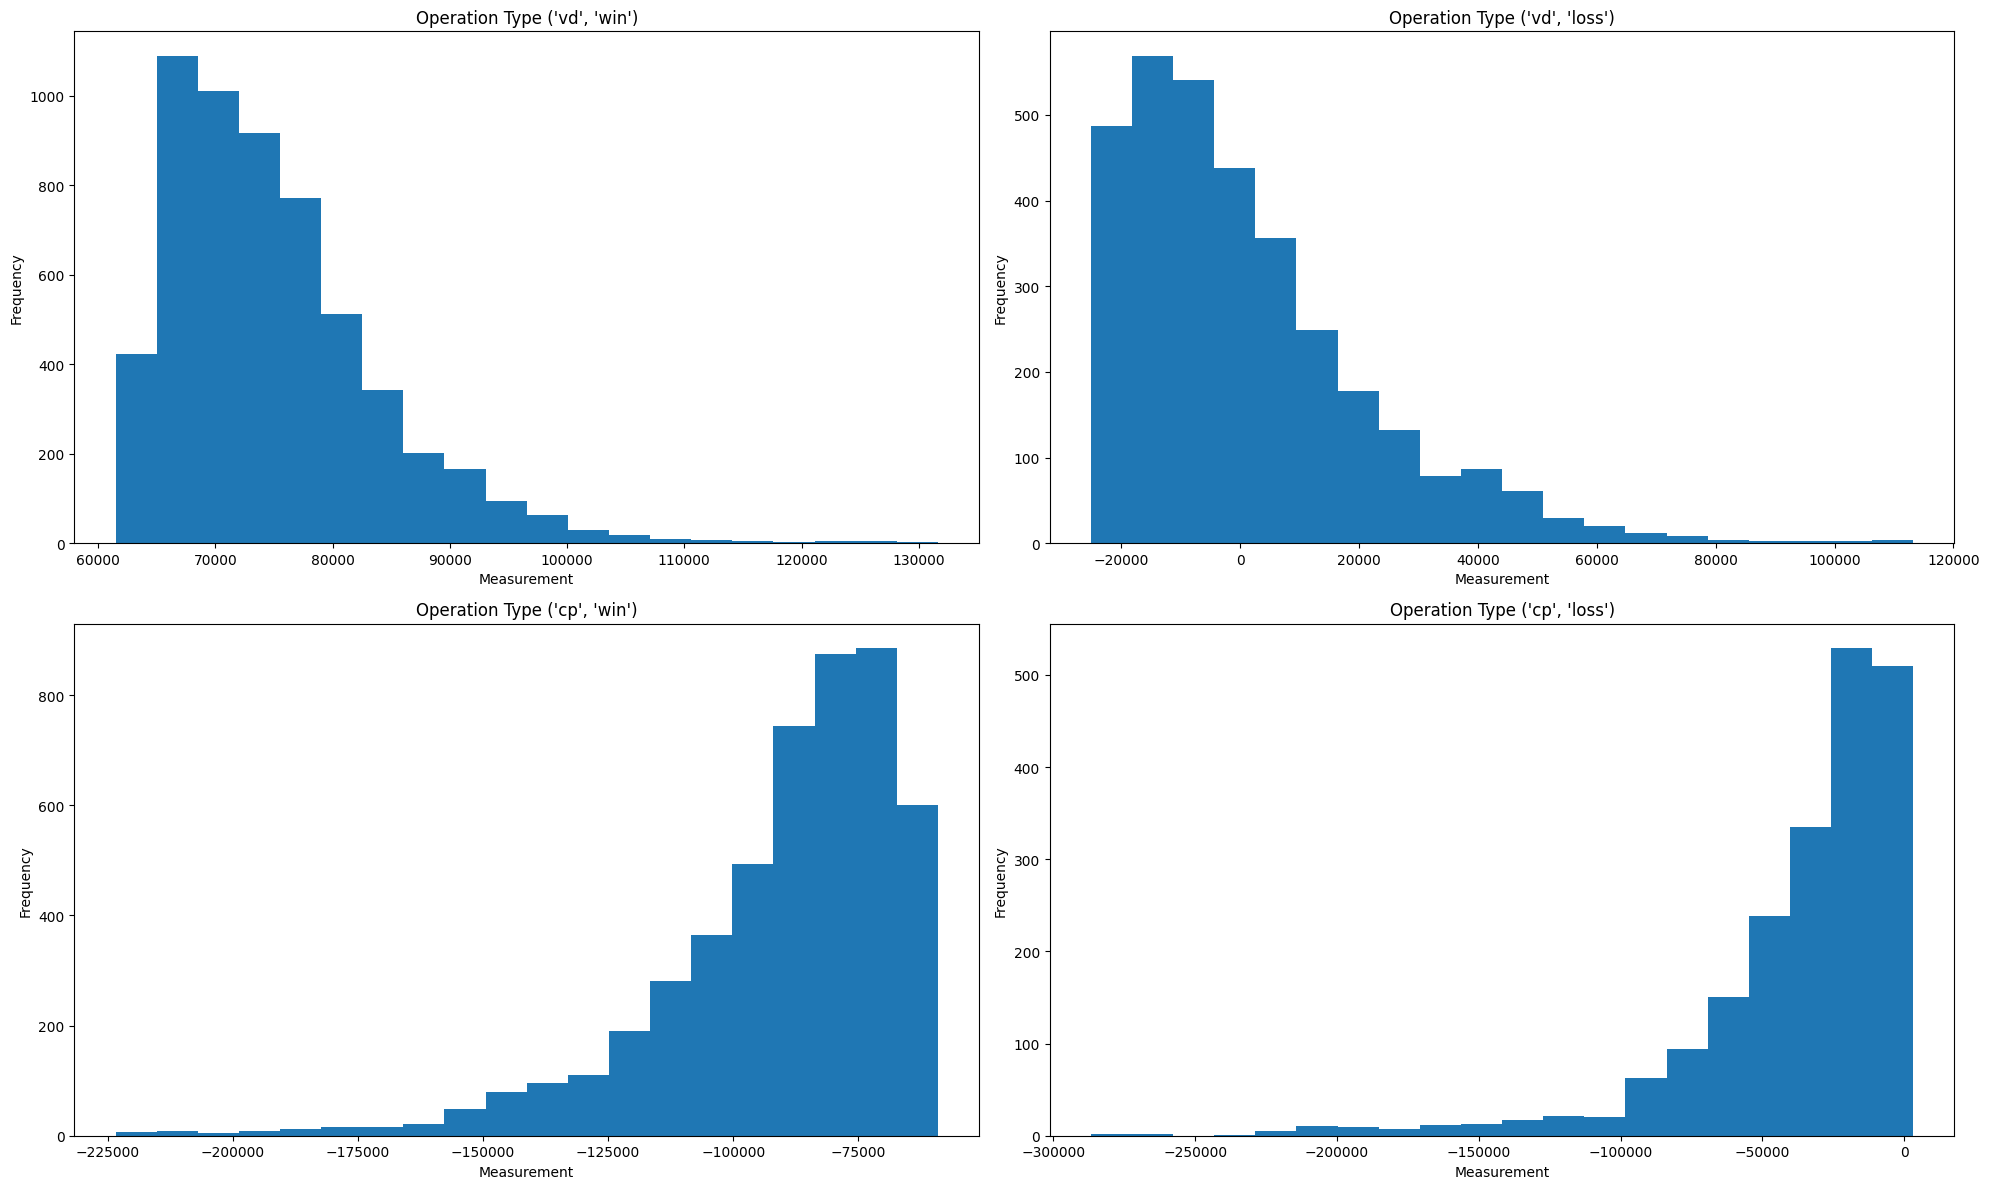

In [21]:
n_operation_types = len(OPERATION_TYPES)
n_cols = 2
n_rows = (n_operation_types + n_cols - 1) // n_cols

plt.figure(figsize=(10 * n_cols, 6 * n_rows))

for index, operation_type in enumerate(OPERATION_TYPES):
    measurements = []

    for dataframe in operation_type_dataframes[operation_type]:
        if 'measurement' in dataframe.columns:
            measurements.append(dataframe['measurement'])

    if measurements:
        all_measurements = pd.concat(measurements)

        plt.subplot(n_rows, n_cols, index + 1)

        all_measurements.hist(bins=20)
        plt.title(f"Operation Type {operation_type}")
        plt.xlabel('Measurement')
        plt.ylabel('Frequency')
        plt.grid(False)

    else:
        print(f"No 'measurement' data available for Operation Type {operation_type}.")

plt.tight_layout()
plt.show()


In [23]:
app = dash.Dash(__name__)

app.layout = html.Div([
    dcc.Slider(
        id='concentration-slider',
        min=50,
        max=99,
        value=80,
        marks={i: f'{i}%' for i in range(50, 100, 5)},
        step=0.1,
    ),
    dcc.Graph(id='measurement-plot'),
])

@app.callback(
    Output('measurement-plot', 'figure'),
    [Input('concentration-slider', 'value')]
)
def update_figure(selected_concentration):
    fig = go.Figure()

    for operation_type in OPERATION_TYPES:
        measurements = []

        for dataframe in operation_type_dataframes[operation_type]:
            if 'measurement' in dataframe.columns:
                measurements.append(dataframe['measurement'])

        if measurements:
            all_measurements = pd.concat(measurements)

            mean = all_measurements.mean()
            std = all_measurements.std()

            z_score = stats.norm.ppf((1 + selected_concentration / 100) / 2)

            lower_bound = mean - z_score * std
            upper_bound = mean + z_score * std

            filtered_measurements = all_measurements[(all_measurements >= lower_bound) & (all_measurements <= upper_bound)]

            fig.add_trace(go.Histogram(x=filtered_measurements, name=str(operation_type), opacity=0.75))

    fig.update_layout(
        title_text=f"Aggregated 'measurement' Data by Operation Type ({selected_concentration}% Concentration)",
        xaxis_title_text='Measurement',
        yaxis_title_text='Frequency',
        barmode='overlay',
        legend_title_text='Operation Type',
        hovermode='x unified',
    )

    fig.update_traces(marker=dict(line=dict(width=0.5, color='white')))

    return fig

if __name__ == '__main__':
    app.run(debug=True)


## Next Steps

- Labelling
- Evaluating
- Testing